# Control de calidad de estaciones de ground truth

Esta notebook continúa el trabajo de `02-ground_truth_dataset.ipynb`, que descargó y preseleccionó 66 estaciones de precipitación sub-horaria (2024-2025) por cobertura temporal y densidad de registros.

Aquí se audita la calidad de esas 66 desde tres frentes: metadatos del catálogo IDEAM (tecnología, fechas de instalación, estado operativo), precisión decimal del instrumento frente al umbral operativo de 0.1 mm/h (Ban et al., 2015), y homogeneidad de las series diarias (saltos abruptos, huecos de cobertura, consistencia espacial frente al cluster geográfico de cada estación). De ahí surgen candidatas a exclusión, que se investigan individualmente y se resuelven bajo tres criterios explícitos:

- **Criterio #1 — Resolución instrumental insuficiente:** se documenta como limitación, sin excluir, cuando el instrumento no alcanza el piso de detección del umbral operativo.
- **Criterio #2 — Contaminación física confirmada:** se excluye cuando existe un mecanismo físico identificable, no relacionado con precipitación, que persiste tras remover episodios puntuales.
- **Criterio #3 — Anomalía estadística no explicada:** se excluye cuando hay desviación sistemática y recurrente frente al cluster geográfico, sin mecanismo físico confirmado — estándar de evidencia menor al #2, apoyado en el peso acumulado de la evidencia.

**Resultado de esta notebook:** 59 de 66 estaciones pasan el control de calidad, guardadas en `estaciones_finales-despues_de_qc.txt`. Esa lista es el insumo de `04-ground_truth_labels.ipynb`, donde se define el umbral operativo de lluvia fuerte y se construye el conjunto de datos etiquetado.

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

import os
import time
from datetime import datetime

from math import gcd
from functools import reduce

import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster

## 1. Preprocesamiento de los datos

Antes de entrar a los tres frentes de control de calidad (metadatos, precisión decimal, inspección visual), se construyen aquí las herramientas de cómputo que se reusan en el resto de la notebook: la tabla resumen de estadísticos por estación y temporada, y la agrupación geográfica de estaciones en clusters — ambas necesarias para comparar cada estación contra su entorno más adelante.

In [2]:
# Lista de las 66 estaciones ya seleccionadas según la sección 2 de ground_truth_labels.ipynb
estaciones_gt = pd.read_csv('estaciones_ground_truth.csv', dtype={'estacion': str})
catalogo_gt = pd.read_csv('estaciones_sabana_candidatas.csv', dtype={'codigo': str})
codigos_gt = estaciones_gt['estacion'].tolist()
print(f"Estaciones a verificar: {len(codigos_gt)}")

Estaciones a verificar: 66


### 1.1 Estadísticos por estación y temporada

Se define el ciclo completo de ocho temporadas del año (DEF, MAM, JJA, SON para 2024 y 2025) y las funciones para cargar los registros sub-horarios, agregarlos a precipitación diaria, y calcular — por estación y por temporada — el porcentaje de días con dato, los descriptivos de precipitación (media, máximo, percentiles), la fecha y magnitud del día más lluvioso, y la cadencia media de reporte. El resultado es `df_temporadas`, la tabla base que alimenta el resto de la notebook.

In [3]:
# Funciones para crear tabla resumen de control de calidad por estación
BANDAS = {
    'DEF_24': ('2023-12-01', '2024-03-01'),  # diciembre 2023 no existe en datos — quedará casi vacía
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'JJA_24': ('2024-06-01', '2024-09-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'DEF_25': ('2024-12-01', '2025-03-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'JJA_25': ('2025-06-01', '2025-09-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}

# Distribución de resolución entre las estaciones
RUTA_BASE = r'..\..\data\rainfall_subhourly'


def cargar_datos_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo (registros sub-horarios) de una estación."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    return df


def agregar_precip_diaria(df):
    """Agrega registros sub-horarios a precipitación diaria (mm/día)."""
    precip_diaria = df.groupby(df['fechaobservacion'].dt.date)['valorobservado'].sum()
    precip_diaria.index = pd.to_datetime(precip_diaria.index)
    return precip_diaria


def stats_temporada(serie_diaria, ini, fin):
    """% de días con dato, descriptivos de precipitación y fecha/valor del máximo, dentro de una ventana."""
    rango = pd.date_range(ini, fin, freq='D', inclusive='left')
    ventana = serie_diaria.reindex(rango)
    desc = ventana.describe()
    if ventana.notna().any():
        fecha_max = ventana.idxmax()
        max_precip = ventana.max()
    else:
        fecha_max = pd.NaT
        max_precip = np.nan
    return {
        'pct_dias_con_dato': ventana.notna().mean(),
        'prec_media': desc.get('mean', np.nan),
        'prec_max': desc.get('max', np.nan),
        'prec_25': desc.get('25%', np.nan),
        'prec_50': desc.get('50%', np.nan),
        'prec_75': desc.get('75%', np.nan),
        'fecha_max_precip': fecha_max,
        'max_precip': max_precip,
    }


def cadencia_media_min(df, ini, fin):
    """Intervalo promedio (minutos) entre registros consecutivos, dentro de una ventana."""
    ventana = df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)]
    deltas = ventana['fechaobservacion'].sort_values().diff().dt.total_seconds() / 60
    deltas = deltas.dropna()
    return deltas.mean() if len(deltas) > 0 else np.nan

In [4]:
# Tabla resumen de control de calidad por estación

# --- Coordenadas + altitud (consulta en vivo al catálogo IDEAM, no viene en el CSV local) ---
catalogo_rows = []
offset = 0
while True:
    resp = requests.get("https://www.datos.gov.co/resource/hp9r-jxuu.json",
                         params={"$limit": 1000, "$offset": offset})
    batch = resp.json()

    if not isinstance(batch, list):
        print(f"⚠️ Respuesta inesperada en offset {offset}: {batch}")
        break

    if not batch:
        break

    catalogo_rows.extend(batch)
    offset += 1000

print(f"{len(catalogo_rows)} registros descargados del catálogo")

df_catalogo_completo = pd.DataFrame(catalogo_rows)
altitud_por_codigo = df_catalogo_completo[df_catalogo_completo['codigo'].isin(codigos_gt)][['codigo', 'altitud']].copy()
altitud_por_codigo['altitud'] = altitud_por_codigo['altitud'].astype(float)

coords = catalogo_gt[['codigo', 'nombre', 'latitud', 'longitud']].copy()
coords = coords[coords['codigo'].isin(codigos_gt)].copy()
coords['latitud'] = coords['latitud'].astype(float)
coords['longitud'] = coords['longitud'].astype(float)
coords = coords.merge(altitud_por_codigo, on='codigo', how='left')

columnas_extra_catalogo = [c for c in ['altitud', 'tecnologia'] if c in catalogo_gt.columns]
if 'altitud' not in columnas_extra_catalogo:
    columnas_extra_catalogo.append('altitud')  # viene del fetch en vivo, no de catalogo_gt
if columnas_extra_catalogo:
    otras_columnas = [c for c in columnas_extra_catalogo if c != 'altitud' and c in catalogo_gt.columns]
    if otras_columnas:
        coords = coords.merge(catalogo_gt[['codigo'] + otras_columnas], on='codigo', how='left')

print(f"Altitud recuperada para {coords['altitud'].notna().sum()} de {len(coords)} estaciones")

# --- Loop principal por estación ---
filas = []
series_diarias = {}

for codigo in coords['codigo']:
    try:
        df_estacion = cargar_datos_estacion(codigo)
    except FileNotFoundError:
        continue

    serie = agregar_precip_diaria(df_estacion)
    series_diarias[codigo] = serie

    fila = {'codigo': codigo}
    for nombre, (ini, fin) in BANDAS.items():
        s = stats_temporada(serie, ini, fin)
        fila[f'{nombre}_mean_dias_con_dato'] = s['pct_dias_con_dato']
        fila[f'{nombre}_prec_media'] = s['prec_media']
        fila[f'{nombre}_prec_max'] = s['prec_max']
        fila[f'{nombre}_prec_25'] = s['prec_25']
        fila[f'{nombre}_prec_50'] = s['prec_50']
        fila[f'{nombre}_prec_75'] = s['prec_75']
        fila[f'{nombre}_prec_max'] = s['prec_max']
        fila[f'{nombre}_fecha_max_precip'] = s['fecha_max_precip']
        fila[f'{nombre}_max_precip'] = s['max_precip']
        fila[f'{nombre}_cadencia_media'] = cadencia_media_min(df_estacion, ini, fin)

    valores = np.sort(serie.dropna().values)[::-1]
    if len(valores) > 1:
        fila['ratio_max_segundo_max'] = valores[0] / valores[1] if valores[1] > 0 else np.nan
        fila['fecha_max_global'] = serie.idxmax()
        fila['precip_max_global'] = serie.max()
    else:
        fila['ratio_max_segundo_max'] = np.nan
        fila['fecha_max_global'] = pd.NaT
        fila['precip_max_global'] = np.nan

    filas.append(fila)

df_temporadas = pd.DataFrame(filas).merge(coords, on='codigo', how='left')

# --- Orden final de columnas ---
columnas_orden = ['codigo', 'nombre', 'longitud', 'latitud'] + columnas_extra_catalogo
columnas_orden += [f'{n}_mean_dias_con_dato' for n in BANDAS]
for n in BANDAS:
    columnas_orden += [f'{n}_prec_media', f'{n}_prec_25', f'{n}_prec_50', f'{n}_prec_75',
                        f'{n}_prec_max', f'{n}_fecha_max_precip', f'{n}_max_precip']
columnas_orden += [f'{n}_cadencia_media' for n in BANDAS]
columnas_orden += ['ratio_max_segundo_max', 'fecha_max_global', 'precip_max_global']

df_temporadas = df_temporadas[columnas_orden]

columnas_cadencia = [f'{n}_cadencia_media' for n in BANDAS]
columnas_numericas = df_temporadas.select_dtypes(include='number').columns
columnas_redondeo_3 = [c for c in columnas_numericas if c not in columnas_cadencia]

df_temporadas[columnas_redondeo_3] = df_temporadas[columnas_redondeo_3].round(3)
df_temporadas[columnas_cadencia] = df_temporadas[columnas_cadencia].round(1)

df_temporadas.to_csv('resumen_qc_66_estaciones_original.csv', index=False)
df_temporadas.head(2)

9727 registros descargados del catálogo
Altitud recuperada para 66 de 66 estaciones


,codigo,nombre,longitud,latitud,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,...,MAM_24_cadencia_media,JJA_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media,JJA_25_cadencia_media,SON_25_cadencia_media,ratio_max_segundo_max,fecha_max_global,precip_max_global
0,2120000101,ALTOS DE LA ESTANCIA [2120000101],-74.178,4.581,Automática con Telemetría,2960.0,0.549,0.935,0.685,0.857,...,6.4,27.7,2.5,2.4,2.9,4.4,1.8,1.721,2024-11-22,33.9
1,2120000122,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED...,-74.155,4.625,Automática con Telemetría,2557.0,0.549,0.935,0.728,0.835,...,5.2,11.8,2.1,2.2,1.5,2.1,1.2,1.071,2025-10-13,27.0


`df_temporadas` es la tabla base que alimenta el resto de la notebook — una fila por estación, con estadísticos calculados para cada una de las ocho temporadas del ciclo (`DEF_24`, `MAM_24`, `JJA_24`, `SON_24`, `DEF_25`, `MAM_25`, `JJA_25`, `SON_25`).

**Identificación y ubicación** (una columna cada una): `codigo`, `nombre`, `longitud`, `latitud`, `altitud`, `tecnologia`.

**Por cada temporada, se repiten siete columnas** con el prefijo del nombre de la temporada (ej. `MAM_24_...`):
- `mean_dias_con_dato` — fracción de días de la ventana con al menos un registro (0-1). Es la métrica de cobertura usada en toda la notebook `02-ground_truth_dataset.ipynb` para detectar huecos de reactivación tardía.
- `prec_media`, `prec_25`, `prec_50`, `prec_75`, `prec_max` — descriptivos de la precipitación diaria dentro de esa ventana.
- `fecha_max_precip`, `max_precip` — cuándo ocurrió y cuánto llovió el día más lluvioso de esa temporada específica.
- `cadencia_media` — intervalo promedio (minutos) entre registros sub-horarios consecutivos en esa ventana; señal de estabilidad del instrumento, no de lluvia.

**Al final, tres columnas de resumen sobre el ciclo completo** (no por temporada): 
- `ratio_max_segundo_max`: qué tan aislado es el día más lluvioso de la estación frente a su propio segundo lugar histórico.
- `fecha_max_global` y `precip_max_global`: cuándo y cuánto fue ese máximo histórico.

### 1.2 Clusters geográficos

Comparar cada estación contra su entorno solo por cercanía horizontal tiene un punto débil en terreno de cordillera: dos estaciones pueden estar a pocos kilómetros de distancia y aun así tener climatologías de lluvia genuinamente distintas por efecto orográfico, si difieren lo suficiente en altitud. Por eso el criterio de vecindad usado aquí combina dos condiciones, no solo una.

**Definición:** dos estaciones se consideran vecinas —y por lo tanto comparables— solo si cumplen simultáneamente (a) distancia horizontal ≤16 km y (b) diferencia de altitud ≤300 m. Los clusters se construyen con clustering jerárquico de enlace completo sobre esa distancia combinada: una estación solo entra a un grupo si cumple ambas condiciones frente a *todos* los demás miembros, no solo frente al más cercano — esto evita el efecto de encadenamiento que produciría un enlace simple (`method='single'`), donde una cadena de vecinos sucesivos podría terminar uniendo estaciones muy alejadas entre sí.

**Radio horizontal (16 km):** informado por la resolución de detección de convección profunda de Casallas-García et al. (2023).

**Umbral de altitud (300 m):** se estableció a partir de la distribución empírica de diferencias de altitud entre pares de
estaciones horizontalmente cercanas (<16 km) dentro de la propia red — no se identificó un quiebre bimodal claro en esa distribución (mediana 145 m, P75 293 m, máximo 679 m), por lo que el umbral se fija en el percentil 75 aproximado: se conservan como comparables los pares de estaciones cuya diferencia de altitud está dentro del 75% más consistente de la red, excluyendo el cuartil de pares con mayor divergencia altitudinal.

In [5]:
# Cálculo de clusters
umbral_km = 16  # Casallas-García et al. (2023)
umbral_altitud_m = 300  # percentil 75 de diferencias de altitud entre pares cercanos (<16 km) de la propia red — ver celda anterior

coords_cluster = coords.dropna(subset=['latitud', 'longitud', 'altitud']).reset_index(drop=True)
n_sin_altitud = len(coords) - len(coords_cluster)
if n_sin_altitud > 0:
    print(f"⚠️ {n_sin_altitud} estación(es) sin altitud, excluida(s) de este cálculo")

dist_horizontal_km = squareform(pdist(coords_cluster[['latitud', 'longitud']].values)) * 111
dist_altitud_m = squareform(pdist(coords_cluster[['altitud']].values))

DISTANCIA_PROHIBIDA = 1_000_000
dist_efectiva = np.where(dist_altitud_m > umbral_altitud_m, DISTANCIA_PROHIBIDA, dist_horizontal_km)
np.fill_diagonal(dist_efectiva, 0)

Z = linkage(squareform(dist_efectiva, checks=False), method='complete')
coords_cluster['cluster_geografico'] = fcluster(Z, t=umbral_km, criterion='distance')

coords = coords_cluster
df_temporadas = df_temporadas.merge(coords[['codigo', 'cluster_geografico']], on='codigo', how='left')

print(f"{coords['cluster_geografico'].nunique()} clusters calculados (radio {umbral_km} km + altitud ≤{umbral_altitud_m} m)")

10 clusters calculados (radio 16 km + altitud ≤300 m)


In [6]:
# Definición de los clusters
resumen_clusters = coords.groupby('cluster_geografico').agg(
    n_estaciones=('codigo', 'count'),
    altitud_min=('altitud', 'min'),
    altitud_max=('altitud', 'max'),
).reset_index()
resumen_clusters['rango_altitud_m'] = resumen_clusters['altitud_max'] - resumen_clusters['altitud_min']
resumen_clusters = resumen_clusters.sort_values('n_estaciones', ascending=False).reset_index(drop=True)

excede = (resumen_clusters['rango_altitud_m'] > umbral_altitud_m).any()
print(f"{'⚠️ Hay clusters que exceden el umbral' if excede else '✓ Ningún cluster excede el umbral de altitud'} ({umbral_altitud_m} m)\n")

display(resumen_clusters[['cluster_geografico', 'n_estaciones', 'altitud_min', 'altitud_max', 'rango_altitud_m']])

✓ Ningún cluster excede el umbral de altitud (300 m)



,cluster_geografico,n_estaciones,altitud_min,altitud_max,rango_altitud_m
0,2,15,2559.0,2831.0,272.0
1,10,13,2815.0,3090.0,275.0
2,3,12,2553.0,2766.0,213.0
3,5,9,2543.0,2584.0,41.0
4,4,9,2552.0,2747.0,195.0
5,1,2,2548.0,2570.0,22.0
6,9,2,2905.0,3182.0,277.0
7,8,2,3195.0,3227.0,32.0
8,6,1,2872.0,2872.0,0.0
9,7,1,2680.0,2680.0,0.0


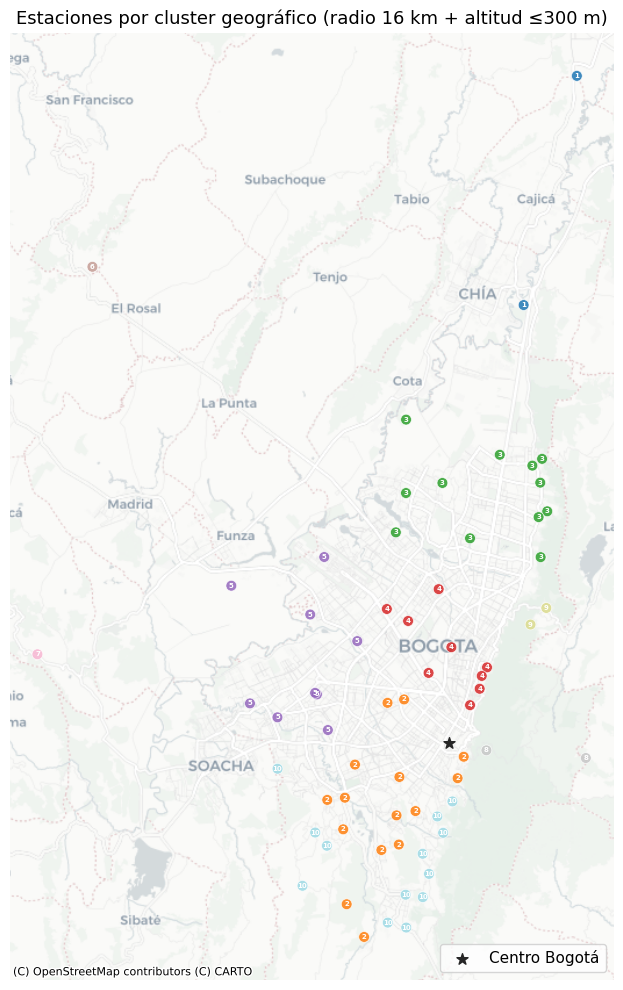

In [7]:
# Estaciones y su cluster en la Sabana de Bogotá
clusters_unicos = sorted(coords['cluster_geografico'].dropna().unique())
cmap = plt.cm.tab20
colores_cluster = {c: cmap(i / max(len(clusters_unicos) - 1, 1)) for i, c in enumerate(clusters_unicos)}

gdf_estaciones = gpd.GeoDataFrame(
    coords, geometry=[Point(xy) for xy in zip(coords['longitud'], coords['latitud'])], crs='EPSG:4326'
).to_crs(epsg=3857)
centro = gpd.GeoDataFrame(geometry=[Point(-74.077, 4.596)], crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_estaciones['color_cluster'] = gdf_estaciones['cluster_geografico'].map(colores_cluster)
gdf_estaciones.plot(ax=ax, color=gdf_estaciones['color_cluster'],
                     markersize=60, alpha=0.85, zorder=3, edgecolor='white', linewidth=0.5)
centro.plot(ax=ax, color='#262626', markersize=70, marker='*', zorder=4, label='Centro Bogotá')

for _, fila in coords.iterrows():
    punto = gpd.GeoSeries([Point(fila['longitud'], fila['latitud'])], crs='EPSG:4326').to_crs(epsg=3857)
    ax.annotate(str(fila['cluster_geografico']), (punto.x.iloc[0], punto.y.iloc[0]),
                fontsize=5, ha='center', va='center', color='white', fontweight='bold')

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)
ax.legend(loc='lower right', fontsize=11)
ax.set_title(f'Estaciones por cluster geográfico (radio {umbral_km} km + altitud ≤{umbral_altitud_m} m)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('img-mapa_clusters_geograficos.png', dpi=200, bbox_inches='tight')
plt.show()

In [8]:
# Distribución de los clusters
coords_validas = coords.dropna(subset=['latitud', 'longitud', 'altitud']).reset_index(drop=True)
dist_horizontal_km = squareform(pdist(coords_validas[['latitud', 'longitud']].values)) * 111
dist_altitud_m = squareform(pdist(coords_validas[['altitud']].values))

# Solo pares horizontalmente cercanos (<16 km) — la pregunta es cuánto difieren en altitud
mask_cercanos = np.triu(dist_horizontal_km < umbral_km, k=1)  # k=1 evita la diagonal y duplicados (i,j)/(j,i)
diferencias_altitud = dist_altitud_m[mask_cercanos]

print(f"{len(diferencias_altitud)} pares de estaciones a <16 km entre sí\n")
print(pd.Series(diferencias_altitud).describe())

1290 pares de estaciones a <16 km entre sí

count    1290.000000
mean      184.938760
std       172.859284
min         0.000000
25%        32.250000
50%       145.000000
75%       293.000000
max       679.000000
dtype: float64


### 1.3 Consistencia espacial (`ratio_p95_cluster`)

Sobre los clusters ya definidos, se calculan tres columnas nuevas que comparan cada estación contra su entorno geográfico inmediato — la métrica principal que se usa en el resto de la notebook para detectar estaciones que se desvían de sus vecinas:

- **`p95_propia`** — el percentil 95 de la serie diaria de la estación: el nivel de precipitación que solo el 5% de sus propios días supera.
- **`p95_cluster_prom`** — el promedio del `p95_propia` de las demás estaciones de su mismo cluster (la estación misma queda excluida del promedio, para no compararse consigo misma).
- **`ratio_p95_cluster`** — `p95_propia` dividido entre `p95_cluster_prom`. Cercano a 1 indica un nivel general similar al de su entorno; por debajo de 1, la estación reporta sistemáticamente menos que sus vecinas (subreporte); por encima de 1, reporta más (sobrerreporte). Estaciones únicas en su cluster (sin vecinas con quién comparar) quedan con `NaN` en las tres columnas.

In [9]:
def p95_estacion(codigo):
    return series_diarias[codigo].quantile(0.95) if codigo in series_diarias else np.nan

df_temporadas['p95_propia'] = df_temporadas['codigo'].apply(p95_estacion)

p95_cluster_prom = {}
for cluster_id, grupo in df_temporadas.groupby('cluster_geografico'):
    codigos_cluster = grupo['codigo'].tolist()
    for codigo in codigos_cluster:
        resto_cluster = [c for c in codigos_cluster if c != codigo]
        if len(resto_cluster) == 0:
            p95_cluster_prom[codigo] = np.nan  # única estación de su cluster — sin vecinas para comparar
        else:
            p95_cluster_prom[codigo] = np.nanmean([p95_estacion(c) for c in resto_cluster])
            #p95_cluster_prom[codigo] = np.mean([p95_estacion(c) for c in resto_cluster])

df_temporadas['p95_cluster_prom'] = df_temporadas['codigo'].map(p95_cluster_prom)
df_temporadas['ratio_p95_cluster'] = df_temporadas['p95_propia'] / df_temporadas['p95_cluster_prom']

df_temporadas[['p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']] = df_temporadas[
    ['p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']
].round(2)

# Cuántas estaciones quedan sin comparación posible (únicas en su cluster)
sin_comparacion = df_temporadas['p95_cluster_prom'].isna().sum()
print(f"{sin_comparacion} estación(es) son la única de su cluster geográfico — ratio_p95_cluster queda como NaN para ellas")

df_temporadas.to_csv('resumen_qc_66_estaciones_original.csv', index=False)
df_temporadas.sort_values('ratio_p95_cluster', ascending=False).head(10)[
    ['codigo', 'nombre', 'cluster_geografico', 'p95_propia', 'p95_cluster_prom', 'ratio_p95_cluster']
]

2 estación(es) son la única de su cluster geográfico — ratio_p95_cluster queda como NaN para ellas


,codigo,nombre,cluster_geografico,p95_propia,p95_cluster_prom,ratio_p95_cluster
13,2120500204,IDEAM PUENTE ARANDA [2120500204],2,30.80,7.33,4.20
59,0021205791,EL DORADO CATAM [21205791],5,30.80,8.80,3.50
41,0021206890,CERRO CAZADORES [21206890],9,9.57,6.64,1.44
50,0021205710,JARDIN BOTANICO [21205710],4,14.80,10.26,1.44
63,0021206600,NUEVA GENERACION [21206600],3,14.03,9.73,1.44
64,0021205910,LA COSECHA [21205910],1,15.40,10.72,1.44
39,2120000133,COLEGIO EL MANANTIAL [2120000133],10,9.82,7.23,1.36
20,2120000134,COLEGIO LOS ALPES SEDE A [2120000134],10,9.59,7.25,1.32
49,0035025060,LA BOLSA [35025060],8,12.64,9.55,1.32
12,2120000140,FUNDACIÓN ANA RESTREPO DEL CORRAL [2120000140],3,12.80,9.84,1.30


## 2. Metadatos: catálogo de estaciones IDEAM

Se consulta el catálogo nacional de estaciones (`hp9r-jxuu`) para las 66 estaciones seleccionadas, revisando los campos de tecnología del instrumento y estado operativo.

In [15]:
# Catálogo nacional de estaciones IDEAM (hp9r-jxuu) — reutiliza df_catalogo_completo,
# ya descargado en la Sección 1.3, para no consultar el mismo endpoint dos veces
print(f"Total de estaciones en el catálogo nacional: {len(df_catalogo_completo)}")
print(f"Columnas disponibles: {df_catalogo_completo.columns.tolist()}")

Total de estaciones en el catálogo nacional: 9691
Columnas disponibles: ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado', 'departamento', 'municipio', 'ubicaci_n', 'altitud', 'longitud', 'latitud', 'fecha_instalacion', 'area_operativa', 'area_hidrografica', 'zona_hidrografica', 'subzona_hidrografica', 'entidad', 'corriente', 'fecha_suspension']


In [10]:
# Filtrado sobre las 66 estaciones
df_catalogo_gt = df_catalogo_completo[df_catalogo_completo['codigo'].isin(codigos_gt)].copy()
print(f"Estaciones encontradas en el catálogo: {len(df_catalogo_gt)} de {len(codigos_gt)}")

faltantes = set(codigos_gt) - set(df_catalogo_gt['codigo'])
if faltantes:
    print(f"\n⚠️ No encontradas en el catálogo (revisar código manualmente): {sorted(faltantes)}")

cols_relevantes = [c for c in ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado',
                                 'fecha_instalacion', 'fecha_suspension',
                                 'departamento', 'municipio'] if c in df_catalogo_gt.columns]
df_catalogo_gt[cols_relevantes].head(5)

Estaciones encontradas en el catálogo: 66 de 66


,codigo,nombre,categoria,tecnologia,estado,fecha_instalacion,fecha_suspension,departamento,municipio
43,2120000122,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED...,Pluviométrica,Automática con Telemetría,Activa,01/11/2016,NaN,Bogotá,"Bogotá, D.C"
50,2120000169,COLEGIO LA BELLEZA (IED) [2120000169],Pluviométrica,Automática con Telemetría,Activa,01/09/2019,NaN,Bogotá,"Bogotá, D.C"
147,2120000101,ALTOS DE LA ESTANCIA [2120000101],Pluviométrica,Automática con Telemetría,Activa,19/06/2018,NaN,Bogotá,"Bogotá, D.C"
159,2120000173,COLEGIO CARLO FEDERICI (IED) [2120000173],Pluviométrica,Automática con Telemetría,Activa,01/12/2019,NaN,Bogotá,"Bogotá, D.C"
213,2120000120,COLEGIO GUSTAVO MORALES [2120000120],Pluviométrica,Automática con Telemetría,Activa,01/11/2016,NaN,Bogotá,"Bogotá, D.C"


El catálogo trae dos tipos de campo distintos.
- `tecnologia` y `estado` son un snapshot del estado actual, no un historial, y por diseño no permiten detectar si una estación cambió de tecnología o estado *durante* 2024-2025.
- `fecha_instalacion` y `fecha_suspension` sí son campos de fecha con potencial para eso, pero como se ve más abajo, ninguno de los dos aporta una señal para las 66 estaciones seleccionadas: ninguna fecha de instalación cae dentro del período, y `fecha_suspension` no está diligenciada ni siquiera para las estaciones que sí cambiaron de estado. El catálogo, entonces, no permite confirmar cambios de instrumento o reubicación dentro del período, pero tampoco permite descartarlos con certeza para las estaciones marcadas más abajo. Esa verificación recae en la inspección visual de la Sección 3.2.

In [17]:
# Distribución de tecnología y estado
if 'tecnologia' in df_catalogo_gt.columns:
    print("Distribución de tecnología entre las 66 estaciones:")
    print(df_catalogo_gt['tecnologia'].value_counts().to_frame(name='n_estaciones'))

if 'estado' in df_catalogo_gt.columns:
    print("\nDistribución de estado operativo:")
    print(df_catalogo_gt['estado'].value_counts().to_frame(name='n_estaciones'))
    no_activas = df_catalogo_gt[~df_catalogo_gt['estado'].str.contains('Activ', case=False, na=False)]
    if len(no_activas) > 0:
        print(f"\n⚠️ {len(no_activas)} estación(es) sin estado activo — revisar manualmente:")
        cols_estado = [c for c in ['codigo', 'nombre', 'categoria', 'tecnologia', 'estado',
                                     'fecha_instalacion', 'fecha_suspension'] if c in df_catalogo_gt.columns]
        display(no_activas[cols_estado])
    else:
        print("\nTodas las estaciones aparecen activas en el catálogo.")

Distribución de tecnología entre las 66 estaciones:
                                         n_estaciones
tecnologia                                           
Automática con Telemetría                          58
Automática con Telemetría, Convencional             8

Distribución de estado operativo:
                  n_estaciones
estado                        
Activa                      64
Suspendida                   1
En Mantenimiento             1

⚠️ 2 estación(es) sin estado activo — revisar manualmente:


,codigo,nombre,categoria,tecnologia,estado,fecha_instalacion,fecha_suspension
1316,2120000136,COL. LOS PINOS SEDE A [2120000136],Pluviométrica,Automática con Telemetría,Suspendida,01/10/2018,NaN
9435,0035025060,LA BOLSA [35025060],Climatológica Principal,"Automática con Telemetría, Convencional",En Mantenimiento,15/05/1987,NaN


Ocho estaciones tienen registrado tanto instrumento automático como convencional en el mismo sitio, no se toma como hallazgo por sí solo, ya que el campo describe el inventario de instrumentos presentes, no un cambio ocurrido dentro del período.

Dos estaciones no aparecen activas: `2120000136` (Suspendida, instalada en 2018) y `0035025060` (En Mantenimiento, instalada en 1987). Llama la atención que `2120000136`, estando suspendida, no tenga fecha de suspensión registrada, si el catálogo refleja un cambio de estado real, se esperaría que ese campo estuviera diligenciado. Sin esa fecha, no se puede establecer si la suspensión ocurrió dentro o después del período de estudio. Ambas estaciones quedan marcadas para revisión puntual en la inspección visual general de la Sección 3.2, con atención particular a los últimos meses de 2025.

In [18]:
# Verificación de fechas: instalación y suspensión dentro del período de estudio (2024-2025)
# Este chequeo sí puede detectar cambios dentro del período, a diferencia de 'tecnologia'/'estado'
df_catalogo_gt['fecha_instalacion'] = pd.to_datetime(df_catalogo_gt['fecha_instalacion'], errors='coerce')
df_catalogo_gt['fecha_suspension'] = pd.to_datetime(df_catalogo_gt['fecha_suspension'], errors='coerce')

inicio_periodo = pd.Timestamp('2024-01-01')
fin_periodo = pd.Timestamp('2025-12-31')
cols_fechas = ['codigo', 'nombre', 'fecha_instalacion', 'fecha_suspension', 'estado']

# Estaciones instaladas dentro o después del inicio del período de estudio —
# señal de que el registro actual del instrumento es más reciente que el propio período,
# lo que podría indicar una reinstalación o reubicación no documentada de otra forma
instaladas_en_periodo = df_catalogo_gt[df_catalogo_gt['fecha_instalacion'] >= inicio_periodo]
if len(instaladas_en_periodo) > 0:
    print(f"⚠️ {len(instaladas_en_periodo)} estación(es) con fecha de instalación dentro o después del período de estudio:")
    display(instaladas_en_periodo[cols_fechas])
else:
    print("Ninguna estación seleccionada tiene fecha de instalación dentro del período 2024-2025.")

print()

# Estaciones con fecha de suspensión — verificar si cae dentro o después del período
con_suspension = df_catalogo_gt[df_catalogo_gt['fecha_suspension'].notna()]
if len(con_suspension) > 0:
    print("Estaciones con fecha de suspensión registrada:")
    display(con_suspension[cols_fechas])
    dentro_periodo = con_suspension[
        (con_suspension['fecha_suspension'] >= inicio_periodo) &
        (con_suspension['fecha_suspension'] <= fin_periodo)
    ]
    if len(dentro_periodo) > 0:
        print(f"\n🚩 {len(dentro_periodo)} estación(es) suspendida(s) DENTRO del período de estudio — revisar la serie con atención:")
        display(dentro_periodo[cols_fechas])
    else:
        print("\nNinguna suspensión registrada cae dentro del período 2024-2025 (posteriores, no afectan los datos usados).")
else:
    print("Ninguna de las 66 estaciones tiene fecha de suspensión registrada.")

Ninguna estación seleccionada tiene fecha de instalación dentro del período 2024-2025.

Ninguna de las 66 estaciones tiene fecha de suspensión registrada.


Ninguna de las 66 estaciones tiene fecha de instalación dentro de 2024-2025 — descarta la señal más directa que este catálogo podía ofrecer sobre una reinstalación o reubicación no documentada de otra forma. La fecha de suspensión no está diligenciada para ninguna estación, incluidas las dos marcadas como no activas, así que el catálogo tampoco permite confirmar ni descartar si esos cambios de estado cayeron dentro del período de estudio.

Con esto se cierra la revisión de metadatos: no aporta evidencia de cambios dentro de 2024-2025 para ninguna de las 66 estaciones, pero deja a `2120000136` y `0035025060` sin resolver, pendientes de la inspección visual directa de sus series completas. El resto de series temporales no requiere seguimiento adicional derivado de esta sección.

## 3. Precisión decimal de los pluviómetros

El umbral de 0.1 mm/h usado para definir "hora húmeda" (Ban et al., 2015) asume que los pluviómetros pueden, en principio, distinguir esa magnitud. Si la resolución real de un instrumento es más gruesa que 0.1 mm (por ejemplo, reporta en incrementos de 0.2 o 0.5 mm), el umbral no tiene significado operativo para esa estación — cualquier valor no-cero ya supera por diseño el piso de detección, independientemente de cuánto llovió realmente.

**Método:** para cada estación, se calcula el máximo común divisor de todos sus valores sub-horarios no-cero (escalados a enteros para evitar errores de coma flotante). Ese MCD es la resolución mínima real de incremento del instrumento — el "paso" más pequeño que el sensor es capaz de reportar.

In [11]:
def resolucion_estacion(codigo, ruta_base=RUTA_BASE):
    """Devuelve resolución (MCD), cantidad de valores únicos no-cero, y la lista de esos valores."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    no_cero = df.loc[df['valorobservado'] > 0, 'valorobservado']
    if len(no_cero) == 0:
        return np.nan, 0, []
    valores_unicos = sorted(no_cero.unique())
    enteros = (no_cero * 100).round().astype(int).unique()
    resolucion = reduce(gcd, enteros) / 100
    return resolucion, len(valores_unicos), valores_unicos

In [12]:
# Distribución de resolución real entre las 66 estaciones
resumen_resolucion = []
for codigo in df_catalogo_gt['codigo']:
    try:
        resolucion, n_unicos, valores_unicos = resolucion_estacion(codigo)
        resumen_resolucion.append({
            'codigo': codigo,
            'resolucion_mm': resolucion,
            'n_valores_unicos': n_unicos,
            'valores_unicos': valores_unicos,
        })
    except FileNotFoundError:
        resumen_resolucion.append({'codigo': codigo, 'resolucion_mm': np.nan,
                                     'n_valores_unicos': 0, 'valores_unicos': []})

df_resolucion = pd.DataFrame(resumen_resolucion)
df_resolucion['cumple_umbral_01mm'] = df_resolucion['resolucion_mm'] <= 0.1

umbral_sospecha_artefacto = 0.05
df_resolucion['posible_artefacto'] = df_resolucion['resolucion_mm'] < umbral_sospecha_artefacto

print("Distribución de resolución real entre las 66 estaciones:")
display(df_resolucion['resolucion_mm'].value_counts().sort_index().to_frame(name='n_estaciones'))

casos_a_revisar = df_resolucion[
    (~df_resolucion['cumple_umbral_01mm']) | (df_resolucion['posible_artefacto'])
].copy()

if len(casos_a_revisar) > 0:
    print(f"\n⚠️ {len(casos_a_revisar)} estación(es) a revisar — resolución gruesa (>0.1mm) o sospechosa de artefacto (<0.05mm):")

    casos_a_revisar['motivo'] = casos_a_revisar.apply(
        lambda f: ', '.join(
            (['resolución gruesa'] if not f['cumple_umbral_01mm'] else []) +
            (['posible artefacto'] if f['posible_artefacto'] else [])
        ), axis=1
    )
    casos_a_revisar['primeros_valores'] = casos_a_revisar['valores_unicos'].apply(
        lambda v: ', '.join(f'{x:.3f}' for x in v[:8]) + (' ...' if len(v) > 8 else '')
    )

    display(casos_a_revisar[['codigo', 'resolucion_mm', 'n_valores_unicos', 'motivo', 'primeros_valores']]
            .rename(columns={'resolucion_mm': 'resolución (mm)', 'n_valores_unicos': 'n valores únicos'}))
else:
    print("\nTodas las estaciones tienen resolución razonable (0.05-0.1 mm) y sin señales de artefacto.")

df_resolucion.drop(columns='valores_unicos').to_csv('resolucion_decimal_estaciones.csv', index=False)

Distribución de resolución real entre las 66 estaciones:


,n_estaciones
resolucion_mm,
0.01,1
0.10,63
0.20,2



⚠️ 3 estación(es) a revisar — resolución gruesa (>0.1mm) o sospechosa de artefacto (<0.05mm):


,codigo,resolución (mm),n valores únicos,motivo,primeros_valores
21,2120500135,0.20,36,resolución gruesa,"0.200, 0.400, 0.600, 0.800, 1.000, 1.200, 1.40..."
50,0021205791,0.01,1131,posible artefacto,"0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.00..."
55,0021205910,0.20,39,resolución gruesa,"0.200, 0.400, 0.600, 0.800, 1.000, 1.200, 1.40..."


De las 66 estaciones, 63 reportan una resolución de 0.1 mm, igual al umbral operativo. Tres quedan fuera de ese patrón:

**`2120500135` y `0021205910` — resolución de 0.2 mm.** Los valores no-cero de ambas son múltiplos limpios de 0.2 (0.2, 0.4, 0.6, 0.8...), sin ruido ni valores sueltos rompiendo el patrón — es la resolución real del instrumento, no un artefacto de cálculo. Para estas dos, el umbral de 0.1 mm/h queda por debajo de lo que el sensor puede distinguir: cualquier lectura no-cero ya representa el doble del piso de detección asumido. Se revisan en detalle a continuación.

**`0021205791` — resolución nominal de 0.01 mm, pero con 1,131 valores únicos distintos** (0.001, 0.002, 0.003 mm...), prácticamente cada incremento posible de milésimas. Esto no corresponde a la resolución de un pluviómetro de balancín real — ningún instrumento de este tipo reporta a esa escala — y sugiere una señal de fondo casi continua más que lluvia discretizada en "tips" del instrumento. También amerita revisión en detalle.

### 3.1 Resolución gruesa, sin evidencia de contaminación: `2120500135` y `0021205910`

Ambas estaciones son vecinas geográficas reales bajo el criterio de cluster actualizado (mismo `cluster_geografico`, radio 16 km + diferencia de altitud ≤300 m — su diferencia real es de solo 22 m, 2548 vs. 2570 msnm), y comparten un perfil casi idéntico: misma cobertura por temporada, cadencia prácticamente igual en las temporadas con datos, aunque notablemente más lenta que la referencia general de la red (~2 min). `0021205910` está catalogada como "Automática con Telemetría, Convencional"; `2120500135` no lleva esa etiqueta, pero el perfil compartido sugiere que pertenece al mismo tipo de instrumento o generación de instalación, con el campo de tecnología posiblemente incompleto en el catálogo para este caso puntual.

Es de notar que ninguna de las dos muestra señal de sobrerreporte: `ratio_p95_cluster` de 0.70 y 1.44 (cercano a 1, sin desviación relevante) y `ratio_max_segundo_max` de 1.282 y 1.000 (sin picos aislados sospechosos).

- *Nota metodológica*: al ser las únicas dos estaciones de su cluster,  cada `ratio_p95_cluster` se compara contra una sola estación, no contra un promedio — una comparación de baja potencia estadística, aunque en este caso el resultado (ambas cercanas a 1) no cambia con esa limitación.

**Tratamiento:** se conservan en el dataset final, sin exclusión, bajo el Criterio #1.

#### Criterio #1, Resolución instrumental insuficiente (-limitación-)

El umbral de 0.1 mm/h usado para definir "hora húmeda" no tiene piso de detección real para estas dos estaciones, cuya resolución de reporte es de 0.2 mm — cualquier lectura no-cero ya representa el doble de ese umbral. Se documenta como limitación explícita al reportar el umbral operativo final, no como motivo de exclusión.

In [14]:
# Perfiles de las estaciones 2120500135 y 0021205910
perfil_coarse = df_temporadas[df_temporadas['codigo'].isin(['2120500135', '0021205910'])][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'DEF_25_cadencia_media', 'MAM_25_cadencia_media', 'SON_25_cadencia_media']
]
perfil_coarse

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,MAM_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media
36,2120500135,UNIVERSIDAD DE LA SABANA [2120500135],1,Automática con Telemetría,2548.0,0.0,0.0,0.0,0.462,0.70,1.282,NaN,22.6,14.4,11.6,10.4
64,0021205910,LA COSECHA [21205910],1,"Automática con Telemetría, Convencional",2570.0,0.0,0.0,0.0,0.462,1.44,1.000,NaN,22.5,14.1,11.6,10.6


### 3.2 Anomalía de resolución: `0021205791`, El Dorado

El perfil resumen de esta estación se aparta del patrón observado en las otras dos candidatas de resolución gruesa (Sección 3.1), lo que amerita una revisión individual más profunda antes de decidir su tratamiento en el dataset final.

**Perfil resumen:**

| Métrica | `El Dorado` | `U. De La Sabana` | `La Cosecha` |
|---|---|---|---|
| `ratio_p95_cluster` | 3.5 | 0.70 | 1.44 |
| `ratio_max_segundo_max` | 2.63 | 1.282 | 1.00 |
| Cadencia (SON_24 → SON_25) | 10.4 → 2.0 min | ~22.6 → ~10.4 min | ~22.5 → ~10.6 min |

**Lo que distingue a esta estación:**

- **`ratio_p95_cluster` de 3.5** — más del triple del promedio de su cluster geográfico, muy por encima de las otras dos candidatas de la sección anterior, que rondan 1 (comportamiento normal frente a su entorno).
- **`ratio_max_segundo_max` de 2.63** — su día más extremo se despega también de su propio segundo lugar, algo que no se observa en las otras dos.
- **Cadencia inestable en el tiempo**, y en dirección opuesta a lo esperado: en vez de mantenerse estable como un instrumento más lento por diseño (patrón de `2120500135`/`0021205910`), pasa de 10.4 min en SON_24 a 2.0 min en MAM_25 y SON_25, terminando más rápida que el promedio de la red, no más lenta. Esto no es consistente con un instrumento simplemente más grueso o de una generación distinta; sugiere un comportamiento de reporte variable que amerita explicación aparte.

Se investiga en profundidad en la ***Sección 4.3.1***.

In [15]:
# Perfil de la estación 0021205791
perfil_coarse = df_temporadas[df_temporadas['codigo'].isin(['0021205791'])][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud', 
     'MAM_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'MAM_25_mean_dias_con_dato', 'SON_25_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media',
     'MAM_25_cadencia_media', 'SON_25_cadencia_media']
]
perfil_coarse

,codigo,nombre,cluster_geografico,tecnologia,altitud,MAM_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,MAM_25_mean_dias_con_dato,SON_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,MAM_24_cadencia_media,SON_24_cadencia_media,MAM_25_cadencia_media,SON_25_cadencia_media
59,0021205791,EL DORADO CATAM [21205791],5,Automática con Telemetría,2547.0,0.0,0.352,0.946,0.978,3.5,2.631,NaN,10.4,2.1,2.0


**Conclusión de análisis de precisión decimal del pluviómetro de El Dorado:** el perfil resumen por sí solo ya distingue a esta estación como cualitativamente distinta de las otras dos candidatas de resolución gruesa — no como una variante del mismo problema, sino como un caso que requiere investigación individual.

## 4. Inspección visual: saltos, tramos planos y anomalías

A diferencia del control de densidad ya hecho (que detecta *ausencia* de datos), aquí se busca detectar problemas dentro de los datos que sí están presentes: cambios de nivel abruptos que no correspondan a un evento de lluvia real, tramos sospechosamente constantes (posible sensor atascado), o cambios visibles en la granularidad de los valores reportados.

### 4.1 Cobertura por temporada de lluvia (MAM/SON)
Se grafican las 66 series en una grilla compacta para escaneo visual rápido, agregadas a nivel diario para que el patrón sea legible a esta escala.

In [16]:
def cargar_precip_diaria(codigo):
    """Carga el CSV de una estación y agrega a precipitación diaria — envoltorio sobre las funciones ya definidas en 1.1."""
    return agregar_precip_diaria(cargar_datos_estacion(codigo))


def sombrear_temporada_humeda(ax, anio_inicio, anio_fin, color='#9EB2A4', alpha=0.18):
    """Sombrea las temporadas de lluvia bimodales de Bogotá (MAM y SON) para cada año del rango."""
    for anio in range(anio_inicio, anio_fin + 1):
        ax.axvspan(pd.Timestamp(f'{anio}-03-01'), pd.Timestamp(f'{anio}-06-01'),
                   color=color, alpha=alpha, lw=0, zorder=0)
        ax.axvspan(pd.Timestamp(f'{anio}-09-01'), pd.Timestamp(f'{anio}-12-01'),
                   color=color, alpha=alpha, lw=0, zorder=0)

66 códigos reordenados geográficamente


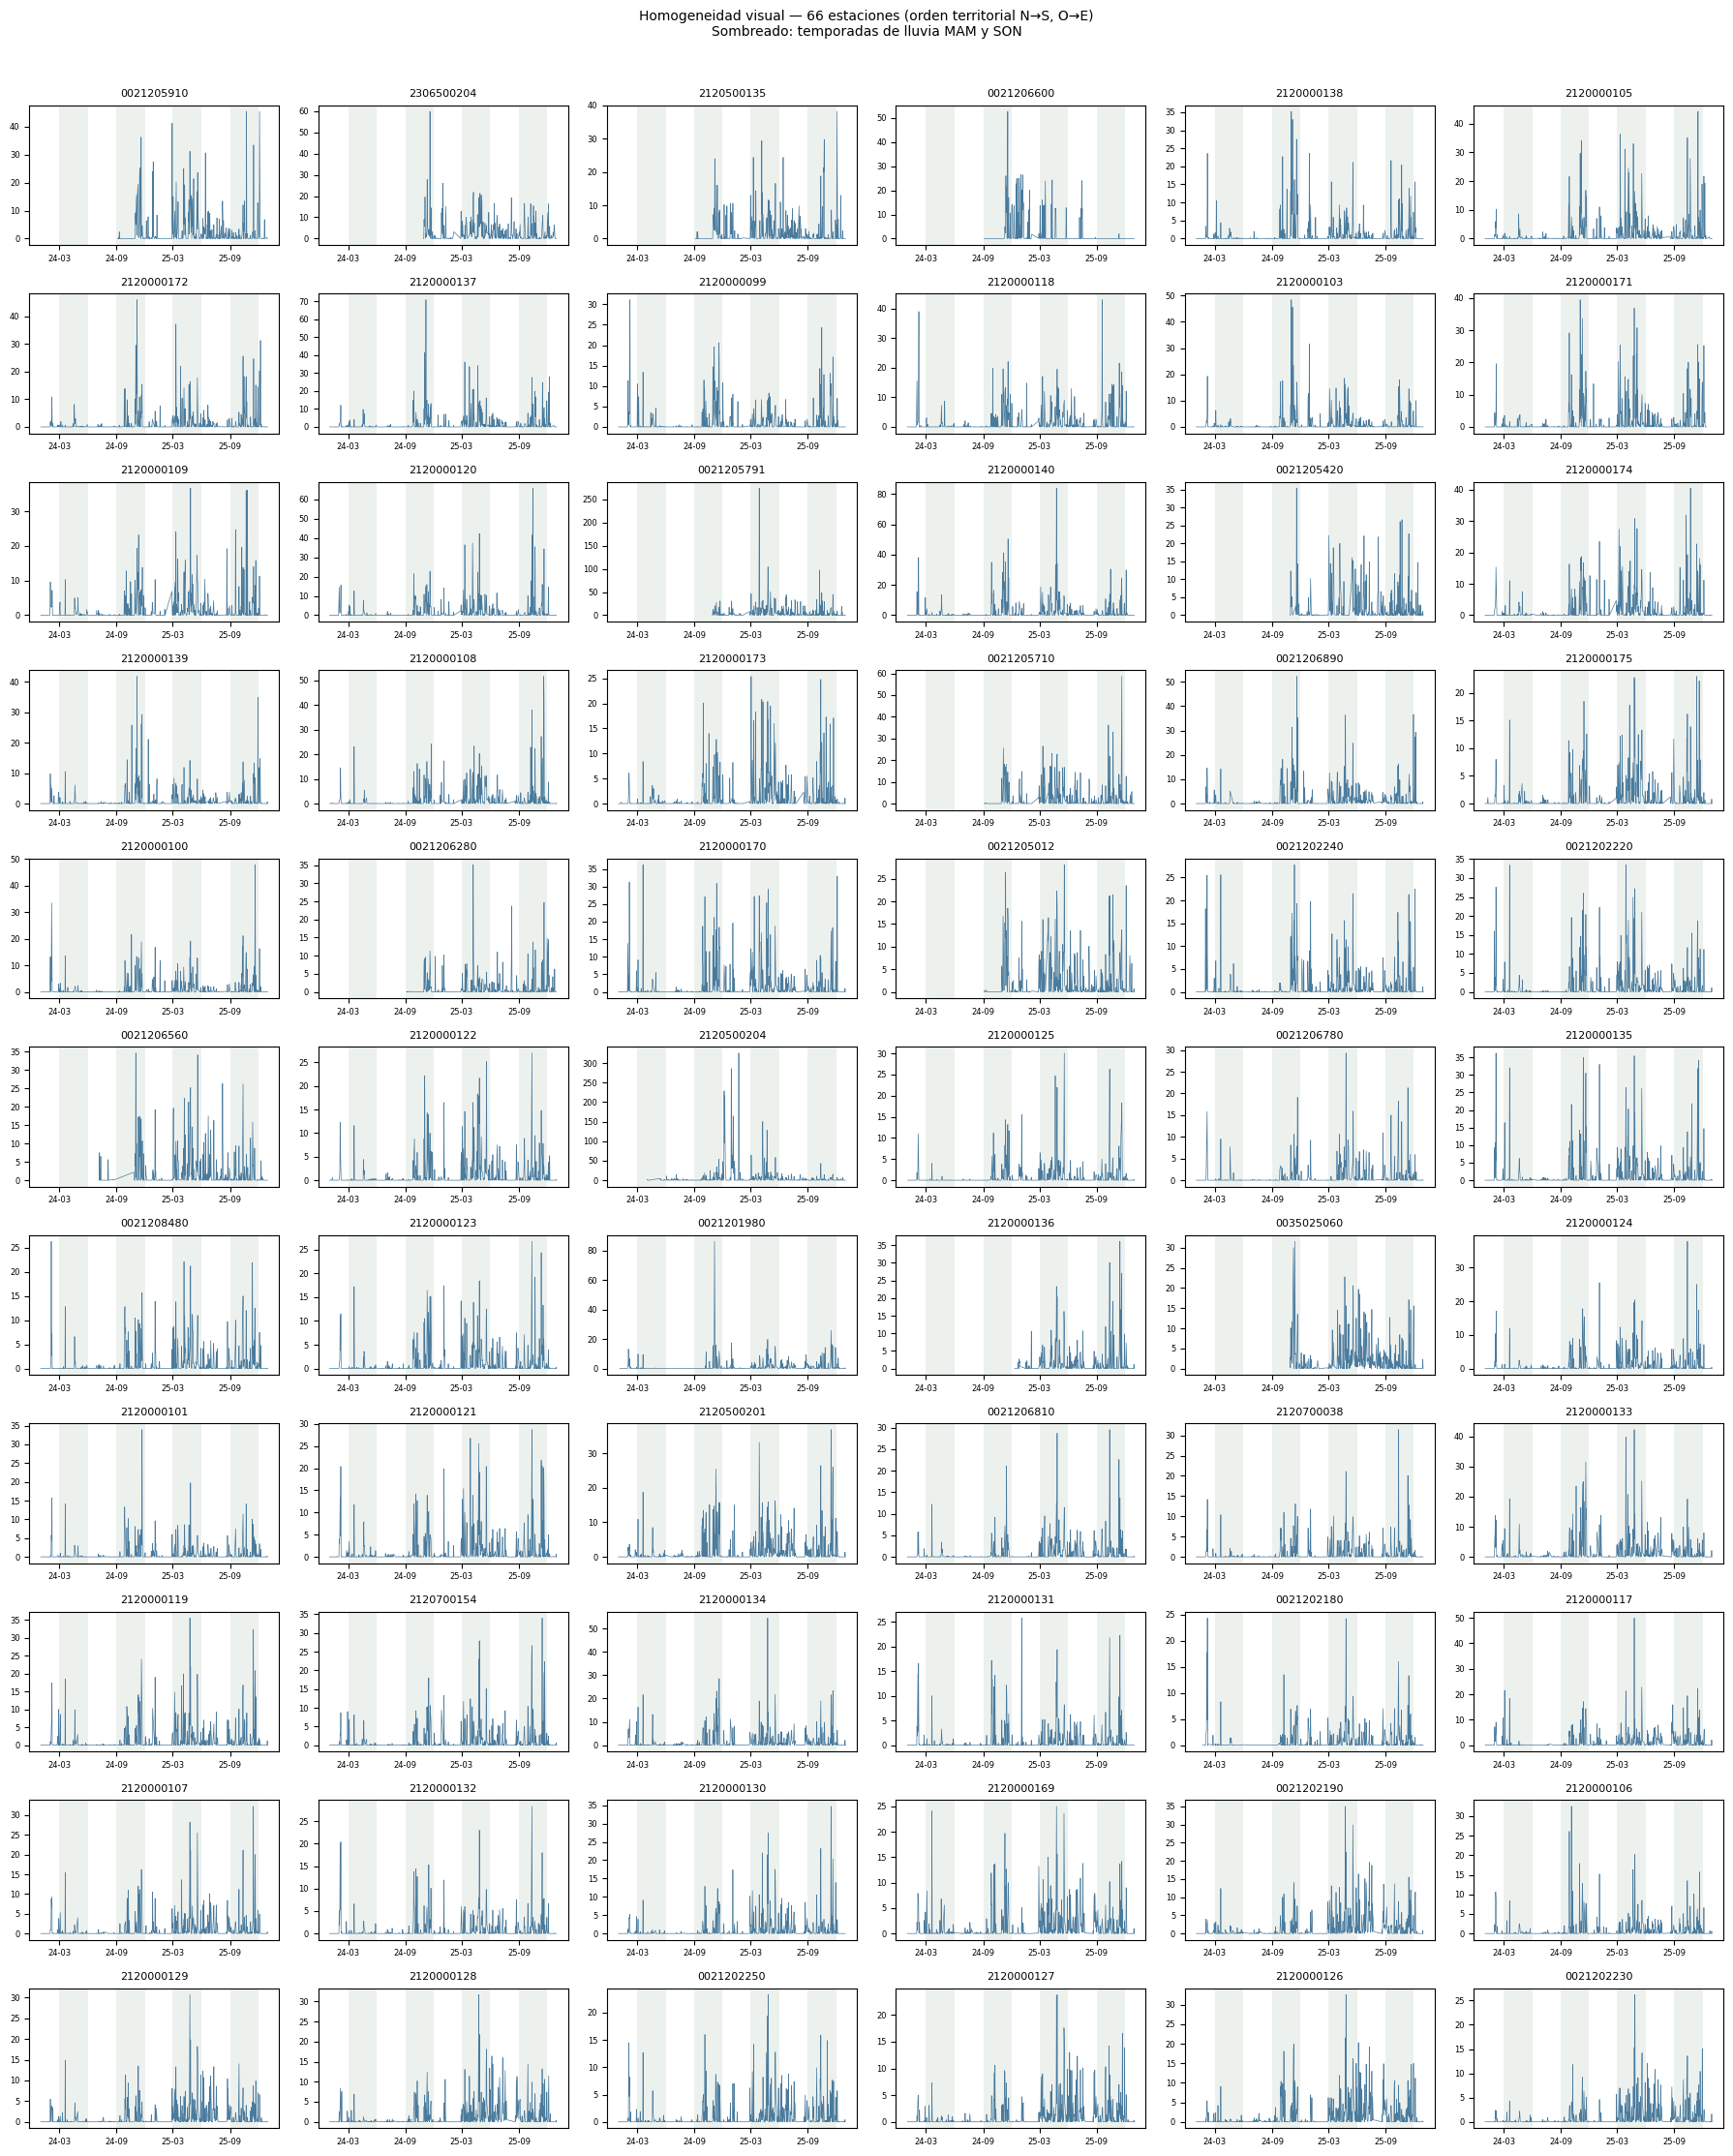

In [17]:
# Vista de las series temporales de las estaciones candidatas, ordenadas territorialmente

# Ordenamiento territorial: norte -> sur como criterio principal,
# oeste -> este como desempate, para que estaciones cercanas
# queden en posiciones consecutivas de la grilla
# (reusa 'coords', ya calculada en la Sección 1 con cluster_geografico y altitud — no se reconstruye)
orden_territorial = coords.sort_values(['latitud', 'longitud'], ascending=[False, True])
codigos_gt_territorial = orden_territorial['codigo'].tolist()

print(f"{len(codigos_gt_territorial)} códigos reordenados geográficamente")

n_cols = 6
n_rows = -(-len(codigos_gt_territorial) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows), sharex=True)
axes = axes.flatten()

series_diarias = {}

for i, codigo in enumerate(codigos_gt_territorial):
    try:
        serie = cargar_precip_diaria(codigo)
        series_diarias[codigo] = serie
        sombrear_temporada_humeda(axes[i], 2024, 2025)
        axes[i].plot(serie.index, serie.values, lw=0.5, color='#4A7B9D', zorder=2)
        axes[i].set_title(codigo, fontsize=8)
        axes[i].tick_params(labelsize=6)
    except FileNotFoundError:
        axes[i].set_title(f"{codigo} (no encontrado)", fontsize=8, color='red')

for j in range(len(codigos_gt_territorial), len(axes)):
    axes[j].axis('off')

# Forzar etiquetas de fecha en TODOS los paneles, no solo la última fila,
# con formato yy-mm y menos ticks para que no se solapen
locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter('%y-%m')

for ax in axes[:len(codigos_gt_territorial)]:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(labelbottom=True, labelsize=6)

fig.suptitle('Homogeneidad visual — 66 estaciones (orden territorial N→S, O→E)\n'
             'Sombreado: temporadas de lluvia MAM y SON', fontsize=10, y=1.01)

plt.tight_layout()
plt.savefig('img-homogeneidad_grid_66_estaciones.png', dpi=150, bbox_inches='tight')
plt.show()

El sombreado de las temporadas bimodales de Bogotá (MAM y SON) sobre la grilla territorial deja ver, a simple vista, que **MAM 2024 tiene notoriamente menos datos** que las otras tres franjas en la mayoría de los paneles, pareciendo que en general la serie suele arrancar recién hacia SON 2024. Esto es consistente con lo ya documentado sobre la reactivación tardía de la red en 2023-2024.

A continuación se cuantifica esto con precisión (por estación, no solo a simple vista) antes de sacar conclusiones sobre su impacto en el cálculo del umbral operativo.

### 4.2 Trayectoria de cobertura y estabilización de la red

La trayectoria de cobertura por estación a través de las cuatro temporadas muestra dos comportamientos claramente diferenciados:

- **Mayoría estable:** la mayor parte de las 66 estaciones mantiene una cobertura alta (~0.80–0.95) de forma prácticamente constante en las cuatro ventanas, sin una tendencia marcada de mejora ni deterioro.

- **Un subgrupo con arranque bajo y recuperación progresiva:** un conjunto menor de estaciones parte de coberturas muy inferiores en MAM 2024, no de forma binaria (0% o 100%), sino en un espectro de puntos de partida (desde 0% hasta ~68%), y converge hacia el mismo rango que la mayoría hacia MAM/SON 2025. La convergencia es progresiva a través de las cuatro ventanas, no un salto abrupto entre dos de ellas.

Distinguiendo por tipo de sensor (línea sólida = automática; punteada = automática + convencional), ambos subtipos de tecnología están presentes dentro del grupo de arranque bajo, y ambos siguen una trayectoria de recuperación con la misma forma general. Esto sugiere que el fenómeno no es exclusivo de un tipo de sensor: la tecnología híbrida coincide con parte del grupo de arranque bajo, pero no lo explica por completo, ya que estaciones puramente automáticas muestran el mismo patrón.

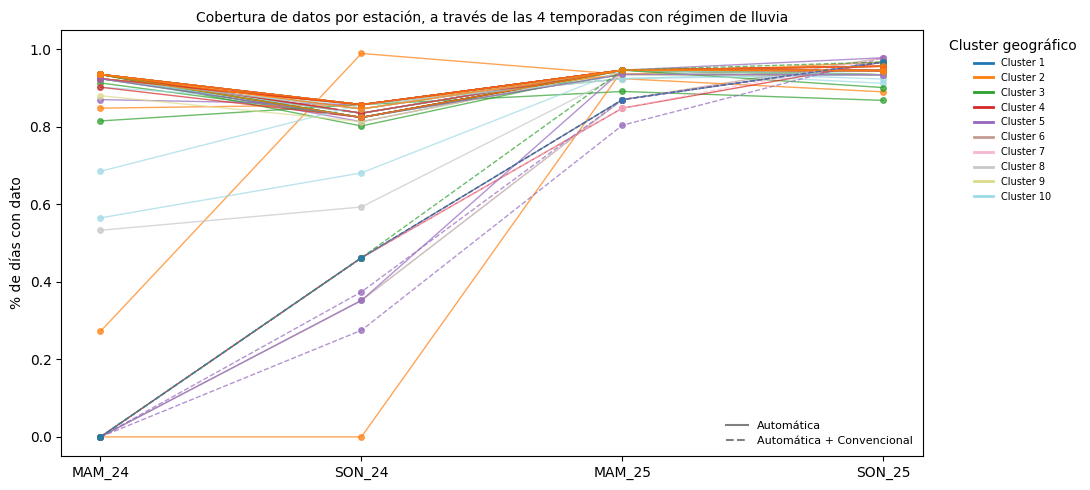

In [18]:
# Porcentaje de días con datos por estación en época de lluvia
temporadas_orden = ['DEF_24', 'MAM_24', 'JJA_24', 'SON_24', 'DEF_25', 'MAM_25', 'JJA_25', 'SON_25']
temporadas_orden_lluvia = ['MAM_24', 'SON_24', 'MAM_25', 'SON_25']

estilos_linea = {
    'Automática con Telemetría': '-',
    'Automática con Telemetría, Convencional': '--',
}

fig, ax = plt.subplots(figsize=(11, 5))

for _, fila in df_temporadas.iterrows():
    valores = [fila[f'{t}_mean_dias_con_dato'] for t in temporadas_orden_lluvia]
    ax.plot(temporadas_orden_lluvia, valores,
            color=colores_cluster.get(fila['cluster_geografico'], '#888780'),
            linestyle=estilos_linea.get(fila['tecnologia'], '-'),
            marker='o', markersize=4, linewidth=1, alpha=0.7)

ax.set_ylabel('% de días con dato')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Cobertura de datos por estación, a través de las 4 temporadas con régimen de lluvia', fontsize=10)

# Leyenda 1: estilo de línea = tecnología
handles_estilo = [
    Line2D([0], [0], color='gray', linestyle='-', label='Automática'),
    Line2D([0], [0], color='gray', linestyle='--', label='Automática + Convencional'),
]
legend_estilo = ax.legend(handles=handles_estilo, loc='lower right', fontsize=8, frameon=False)
ax.add_artist(legend_estilo)  # necesario para que no se borre al crear la segunda leyenda

# Leyenda 2: color = cluster geográfico
handles_cluster = [
    Line2D([0], [0], color=colores_cluster[c], lw=2, label=f'Cluster {int(c)}')
    for c in sorted(colores_cluster.keys())
]
ax.legend(handles=handles_cluster, bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=7, frameon=False, title='Cluster geográfico')

plt.tight_layout()
plt.savefig('img-cobertura_por_estacion_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

Este resultado tiene coherencia con resultados vistos anteriormente (ver notebook `01-ground_truth_exploration.ipynb`, sección 3.2), donde era visible, considerando, la cobertura completo de la red (2018-2026), que el número de estaciones activas cae a su mínimo en 2021-2022 (12 y 10 estaciones, respectivamente), y aunque 2023 ya cuenta con el número casi final de estaciones (66, prácticamente el mismo total usado en este trabajo), su mediana de registros por estación (7,532) es la más baja de toda la serie histórica,  evidencia de que la infraestructura física ya estaba instalada, pero el reporte todavía no era confiable. Recién en 2024 la mediana sube a 189,785 y en 2025 a 353,808, consolidando el nivel de densidad que sostiene el resto de este trabajo.

La trayectoria de cobertura por temporada (imagen arriba) es, en ese sentido, la misma historia vista con más resolución: no un hallazgo nuevo y separado, sino la cola fina de esa estabilización de red, mostrando en qué momento dentro de 2024, no solo en qué año, cada estación terminó de alcanzar un nivel de reporte confiable.

### 4.3 Coherencia espacial de las fechas de máximo estacional

Se busca inspeccionar visualmente cómo se comporta el pico de precipitación máxima por temporada entre las 66 estaciones, considerando únicamente las ventanas MAM y SON, y agrupando las estaciones por cercanía geográfica (clustering). El objetivo es distinguir dos escenarios distintos que una fecha de máximo compartida entre estaciones no permite diferenciar por sí
sola: una tormenta regional real que afectó a varias estaciones a la vez, o una coincidencia de fecha entre estaciones sin relación geográfica entre sí.

In [19]:
# Tabla larga de picos (una fila por estación-temporada)

registros_pico = []
for _, fila in df_temporadas.iterrows():
    for temporada in temporadas_orden_lluvia:
        fecha = fila[f'{temporada}_fecha_max_precip']
        valor = fila[f'{temporada}_max_precip']
        if pd.notna(fecha) and pd.notna(valor):
            registros_pico.append({
                'codigo': fila['codigo'],
                'fecha': pd.to_datetime(fecha),
                'max_precip': valor,
            })

df_picos = pd.DataFrame(registros_pico)

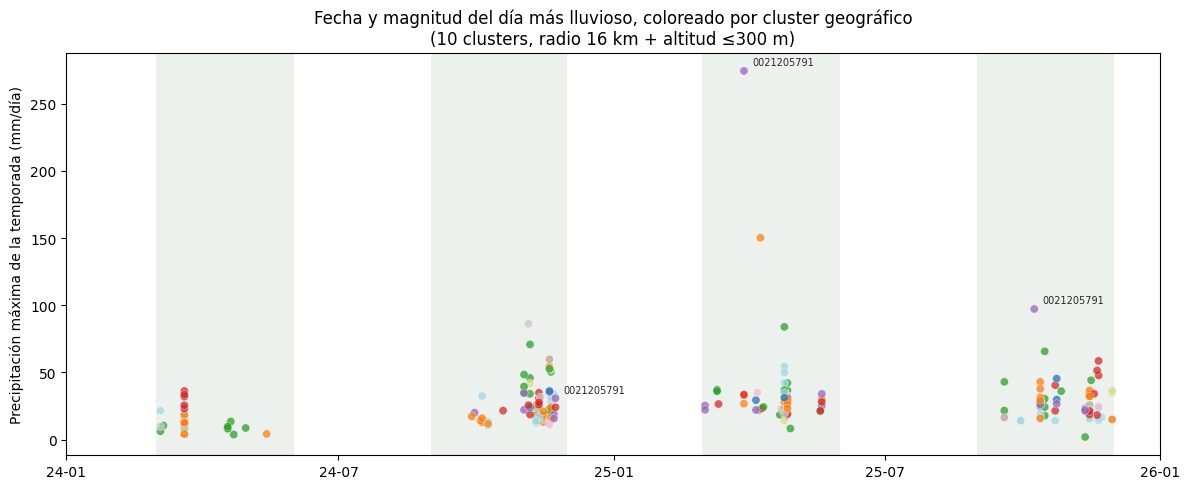

In [20]:
# Día más lluvioso coloreado por cluster geográfico
df_picos = df_picos.drop(columns='cluster_geografico', errors='ignore')
df_picos = df_picos.merge(
    df_temporadas[['codigo', 'cluster_geografico']], on='codigo', how='left')

n_clusters = coords['cluster_geografico'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
sombrear_temporada_humeda(ax, 2024, 2025)

scatter = ax.scatter(df_picos['fecha'], df_picos['max_precip'],
                      c=df_picos['cluster_geografico'].map(colores_cluster),
                      alpha=0.75, s=35, edgecolor='white', linewidth=0.3)

# Etiquetar el punto de El Dorado en cada temporada donde tenga dato
picos_dorado = df_picos[df_picos['codigo'] == '0021205791']
for _, fila in picos_dorado.iterrows():
    ax.annotate('0021205791', (fila['fecha'], fila['max_precip']),
                fontsize=7, xytext=(6, 4), textcoords='offset points', color='#262626')

ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2026-01-01'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
ax.set_ylabel('Precipitación máxima de la temporada (mm/día)')
ax.set_title(f'Fecha y magnitud del día más lluvioso, coloreado por cluster geográfico\n'
             f'({n_clusters} clusters, radio {umbral_km} km + altitud ≤{umbral_altitud_m} m)')

plt.tight_layout()
plt.show()

En las fechas con mayor número de estaciones coincidentes, los colores del gráfico aparecen mezclados, no concentrados en un solo vecindario — es decir, esos eventos cruzan varios grupos geográficos de ~16 km a la vez. Esto es consistente con tormentas regionales reales que cubrieron una porción amplia de la Sabana, más que con un artefacto compartido por un grupo puntual de sensores.

- **Caso aislado — `0021205791`:** esta estación registra su máximo estacional (274 mm, MAM 2025, 2025-03-29) sin compartir fecha con ningún cluster grande de la red, ni con sus vecinas, según el cluster asignado. Al no tener respaldo ni temporal ni espacial de otras estaciones, queda como el único caso de esta revisión que sigue requiriendo verificación individual antes de decidir su tratamiento en el dataset final — no se puede atribuir a tormenta regional con la evidencia disponible hasta ahora.

***Limitación de alcance:*** el análisis de esta sección se restringe a las ventanas MAM/SON — no cubre eventos fuera de esas temporadas, como el máximo global de `2120500204` (651.6 mm, 2025-01-22), que cae en enero y por diseño queda fuera del chequeo de esta sección.

#### 4.3.1 Investigación detallada y decisión de exclusión de la estación `0021205791` (El Dorado)

El perfil resumen (3.2) dejó a `0021205791` como la única de las tres candidatas de resolución gruesa que no se explica por un instrumento distinto sin más — su cadencia inestable y sus ratios elevados exigían mirar la serie directamente, no solo sus estadísticos agregados.

**Primero, la distribución completa contra su vecindario real.** Se comparó la distribución de días húmedos de la estación contra las estaciones que comparten su cluster geográfico (cluster 5; radio 16 km — Casallas-García et al., 2023 — más diferencia de altitud ≤300 m, criterio definido en 1.2).

In [21]:
# coords_validas: mismo contenido que coords, filtrado a estaciones con series cargadas
codigo_objetivo = '0021205791'
coords_validas = coords[coords['codigo'].isin(series_diarias.keys())].reset_index(drop=True)
coords_arr = coords_validas[['latitud', 'longitud']].values

cluster_el_dorado = coords_validas.loc[coords_validas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]
miembros_cluster = coords_validas.loc[
    coords_validas['cluster_geografico'] == cluster_el_dorado, 'codigo'
].tolist()
miembros_cluster = [c for c in miembros_cluster if c != codigo_objetivo]

print(f"Miembros del cluster {cluster_el_dorado} (sin El Dorado): {len(miembros_cluster)} — {miembros_cluster}")

Miembros del cluster 5 (sin El Dorado): 8 — ['2120000122', '2120000173', '2120000123', '2120000175', '0021206780', '0021205420', '0021206560', '0021208480']


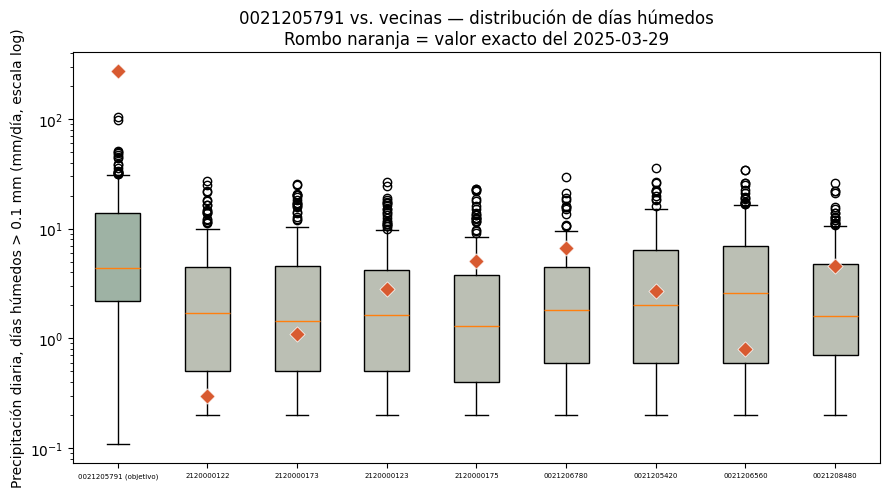

In [22]:
#Distribución de días húmedos del cluster #5
umbral_humedo = 0.1  # mm/día

estaciones_comparar = [codigo_objetivo] + miembros_cluster
fecha_pico = pd.Timestamp('2025-03-29')

datos_boxplot = []
valores_ese_dia = []
etiquetas = []

for codigo in estaciones_comparar:
    serie = series_diarias.get(codigo)
    if serie is None:
        continue
    dias_humedos = serie[serie > umbral_humedo].dropna()
    datos_boxplot.append(dias_humedos.values)
    valores_ese_dia.append(serie.get(fecha_pico, np.nan))
    etiquetas.append(codigo + (' (objetivo)' if codigo == codigo_objetivo else ''))

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(datos_boxplot, tick_labels=etiquetas, showfliers=True,
                 patch_artist=True, widths=0.5)
for patch, codigo in zip(bp['boxes'], estaciones_comparar):
    patch.set_facecolor('#9EB2A4' if codigo == codigo_objetivo else '#BBBFB4')

# El valor puntual del 2025-03-29, marcado aparte
for i, valor in enumerate(valores_ese_dia, start=1):
    if pd.notna(valor):
        ax.scatter(i, valor, color='#D85A30' if valor > 0 else '#888780',
                   s=60, zorder=5, marker='D', edgecolor='white', linewidth=0.5)

ax.set_yscale('log')
ax.set_ylabel('Precipitación diaria, días húmedos > 0.1 mm (mm/día, escala log)')
ax.set_title(f'{codigo_objetivo} vs. vecinas — distribución de días húmedos\n'
             f'Rombo naranja = valor exacto del {fecha_pico.date()}')
plt.xticks(ha='center', fontsize=5)

plt.tight_layout()
plt.show()

De ahí se ve algo más específico que "corre más alto en promedio": el rombo naranja del 2025-03-29 no solo está por encima de las 8 vecinas ese mismo día, está por encima incluso de los propios valores atípicos históricos de la estación (valores que llegan hasta ~90-100 mm). Eso ya distingue este día como algo cualitativamente distinto del comportamiento normal de la estación, no solo un día lluvioso más.

**Con esa pista, se inspecciona el registro sub-horario del 29 de marzo contra un día típico de la misma estación.**

Total del día 29 de marzo: 274.3 mm
Máximo individual: 3.600 mm — participación: 1.3%
Registros no-cero: 151 de 840 (18.0% del día con algo de actividad)


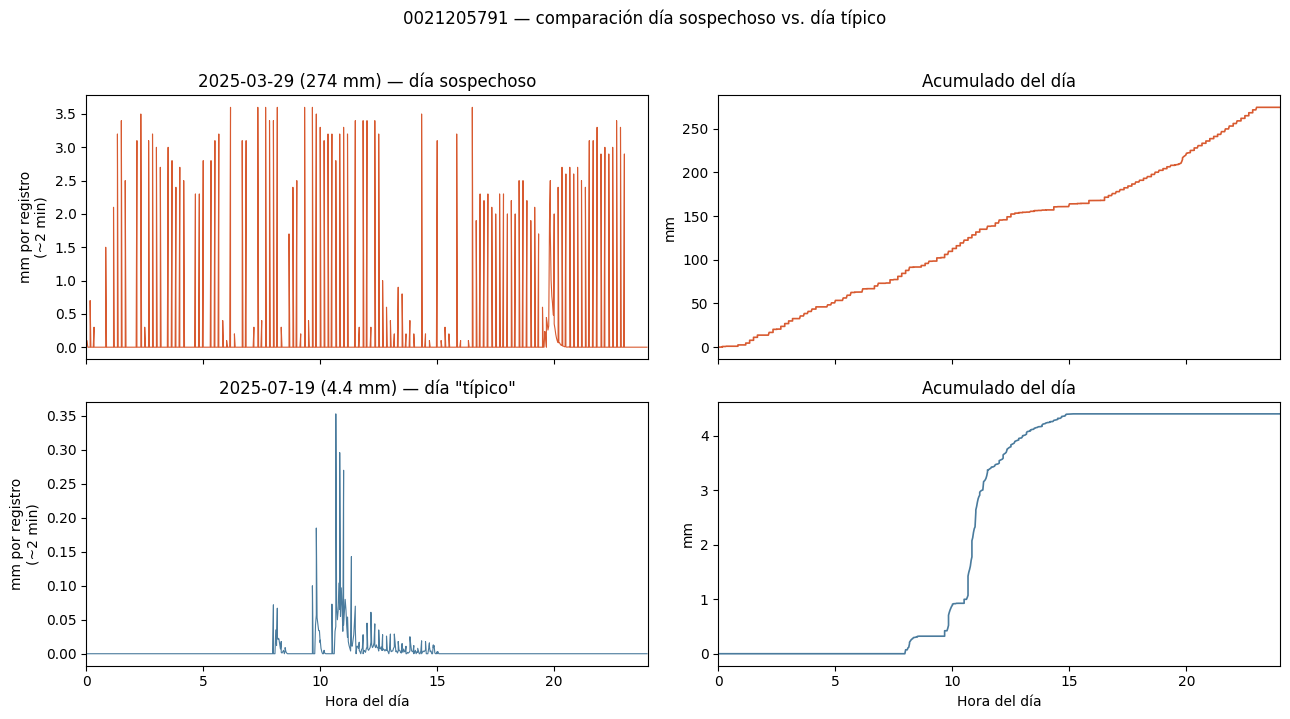

In [23]:
# Comparación de comportamiento de dos días diferentes de la estación El Dorado
ruta = os.path.join(RUTA_BASE, '0021205791.csv')
df_estacion = pd.read_csv(ruta)
df_estacion['fechaobservacion'] = pd.to_datetime(df_estacion['fechaobservacion'])
df_estacion['fecha'] = df_estacion['fechaobservacion'].dt.date

# Números exactos del 29 de marzo
dia_29 = df_estacion[df_estacion['fecha'] == pd.Timestamp('2025-03-29').date()].sort_values('fechaobservacion')
total_29 = dia_29['valorobservado'].sum()
n_no_cero = (dia_29['valorobservado'] > 0).sum()
print(f"Total del día 29 de marzo: {total_29:.1f} mm")
print(f"Máximo individual: {dia_29['valorobservado'].max():.3f} mm — participación: {dia_29['valorobservado'].max()/total_29*100:.1f}%")
print(f"Registros no-cero: {n_no_cero} de {len(dia_29)} ({n_no_cero/len(dia_29)*100:.1f}% del día con algo de actividad)")

# Día "típico" de la misma estación, para comparar
serie_estacion = series_diarias['0021205791']
dias_humedos = serie_estacion[serie_estacion > umbral_humedo]
mediana = dias_humedos.median()
fecha_normal = (dias_humedos.drop(pd.Timestamp('2025-03-29')) - mediana).abs().idxmin()
dia_normal = df_estacion[df_estacion['fecha'] == fecha_normal.date()].sort_values('fechaobservacion')
total_normal = dia_normal['valorobservado'].sum()

# --- Una sola figura: 2x2 — curva y acumulado, día sospechoso arriba, día típico abajo ---
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

hora_29 = dia_29['fechaobservacion'].dt.hour + dia_29['fechaobservacion'].dt.minute / 60
hora_normal = dia_normal['fechaobservacion'].dt.hour + dia_normal['fechaobservacion'].dt.minute / 60

axes[0, 0].plot(hora_29, dia_29['valorobservado'], lw=0.8, color='#D85A30')
axes[0, 0].set_title(f'2025-03-29 ({total_29:.0f} mm) — día sospechoso')
axes[0, 0].set_ylabel('mm por registro\n(~2 min)')

axes[0, 1].plot(hora_29, dia_29['valorobservado'].cumsum(), lw=1.2, color='#D85A30')
axes[0, 1].set_title('Acumulado del día')
axes[0, 1].set_ylabel('mm')

axes[1, 0].plot(hora_normal, dia_normal['valorobservado'], lw=0.8, color='#4A7B9D')
axes[1, 0].set_title(f'{fecha_normal.date()} ({total_normal:.1f} mm) — día "típico"')
axes[1, 0].set_ylabel('mm por registro\n(~2 min)')
axes[1, 0].set_xlabel('Hora del día')

axes[1, 1].plot(hora_normal, dia_normal['valorobservado'].cumsum(), lw=1.2, color='#4A7B9D')
axes[1, 1].set_title('Acumulado del día')
axes[1, 1].set_ylabel('mm')
axes[1, 1].set_xlabel('Hora del día')

for ax in axes.flat:
    ax.set_xlim(0, 24)

fig.suptitle('0021205791 — comparación día sospechoso vs. día típico', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

El contraste es claro: el día típico (2025-04-24, 5.9 mm) muestra dos ráfagas cortas con forma de subida y bajada — compatible con la escala convectiva de ~3 horas documentada para la Sabana (Casallas-García et al., 2023). El 29 de marzo (274 mm), en cambio, muestra picos regulares de magnitud casi constante durante prácticamente 22 horas seguidas, sin la forma de una tormenta real. El acumulado del día lo confirma: sube en escalera sostenida durante todo el día, no en un salto puntual que señalaría un solo valor mal registrado.

**Esa forma lleva a preguntar si el 29 de marzo fue un caso único o parte de un patrón recurrente de esta estación.** Se buscaron días con más de 15 horas de actividad sub-horaria seguida (muy por encima de las ~3h esperadas):

In [24]:
df_estacion['fecha'] = df_estacion['fechaobservacion'].dt.date
df_estacion['hora'] = df_estacion['fechaobservacion'].dt.floor('h')

horas_activas_por_dia = (
    df_estacion[df_estacion['valorobservado'] > 0]
    .groupby('fecha')['hora'].nunique()
)

# Convección real dura ~3h (Casallas-García et al.) — días con muchas más
# horas de actividad (no necesariamente consecutivas) que eso son candidatos
# a goteo mecánico disperso, no a una sola tormenta
sospechosos = horas_activas_por_dia[horas_activas_por_dia > 15].sort_values(ascending=False)
print(f"{len(sospechosos)} de {len(horas_activas_por_dia)} días con >15 horas del día con algo de actividad")
print(sospechosos.head(10))

5 de 230 días con >15 horas del día con algo de actividad
fecha
2025-03-29    24
2025-04-26    18
2025-05-20    18
2025-05-03    16
2025-06-24    16
Name: hora, dtype: int64


El resultado da una minoría pequeña (5 de 230 días), no un patrón que domine la vida de la estación indica que el sensor no está roto todo el tiempo, falla en episodios puntuales.

**Con eso, la pregunta clave: ¿esos 5 episodios explican por completo la elevación sistemática de P95, o hay algo más de fondo?**

In [25]:
serie_sin_outlier = series_diarias['0021205791'].drop(pd.Timestamp('2025-03-29'))
p95_sin_outlier = serie_sin_outlier.quantile(0.95)
p95_vecinas_valor = df_temporadas.loc[df_temporadas['codigo'] == '0021205791', 'p95_cluster_prom'].values[0]

print(f"P95 CON el 29 de marzo: {df_temporadas.loc[df_temporadas['codigo']=='0021205791', 'p95_propia'].values[0]:.2f}")
print(f"P95 SIN el 29 de marzo: {p95_sin_outlier:.2f}")
print(f"P95 promedio de vecinas: {p95_vecinas_valor:.2f}")

P95 CON el 29 de marzo: 30.80
P95 SIN el 29 de marzo: 30.64
P95 promedio de vecinas: 8.80


La respuesta es que no la explican: el P95 apenas se mueve al remover el 29 de marzo (32.42 → 32.32), y sigue más de 3 veces el promedio de su cluster (32.32 / 10.38 = 3.11). Esto separa el problema en dos hallazgos independientes, no uno solo: (1) episodios puntuales de goteo mecánico identificables y corregibles, y (2) una elevación sistemática de fondo que persiste sin ellos y que no se explica por esos episodios.

**Se descartaron, además, las explicaciones alternativas disponibles**: altitud (2547 m, dentro del rango normal de la red — sin respaldo orográfico) y tecnología (sensor catalogado como automático puro, sin la etiqueta "Convencional").

Nota adicional: `0021205791.csv` conserva, para una misma `fechaobservacion`, pares de registros con `valorobservado` distinto entre sí (no son duplicados exactos, y por diseño no se limpiaron en la etapa de deduplicación — ver `01.1-remove_duplicate_records.ipynb` *sección 1.3*). Este patrón de lecturas inconsistentes en el mismo instante es consistente con el mismo mecanismo de contaminación física propuesto para el resto de la sección, y refuerza — no cuestiona — la decisión de exclusión.

***Conclusión: `0021205791` (El Dorado) se excluye del dataset final de ground truth.*** La ubicación (aeropuerto El Dorado) ofrece un mecanismo físico plausible — vibración mecánica del entorno aeroportuario afectando el balancín del pluviómetro — consistente con toda la evidencia reunida: picos regulares no convectivos, elevación persistente incluso sin los episodios más extremos, y ausencia de explicaciones alternativas.

##### Criterio #2, Contaminación física (-excluir-):

Se excluye una estación cuando existe (a) un mecanismo físico de contaminación identificable, no relacionado con precipitación, y (b) la anomalía estadística persiste después de remover los episodios puntuales corregibles.

In [26]:
estaciones_excluidas = ['0021205791']  # El Dorado — contaminación por vibración, ver Sección 3.4.1
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")

df_temporadas = df_temporadas[df_temporadas['codigo'].isin(codigos_finales)].copy()

65 estaciones en el dataset final (de 66)


**Recálculo del pool de comparación tras la exclusión.** Cada vez que se excluye una estación, se recalcula `ratio_p95_cluster` para las estaciones restantes de su mismo cluster antes de investigar la siguiente candidata — no se pospone hasta el final. La razón es el fenómeno de *masking* (enmascaramiento) bien documentado en la detección de outliers múltiples (por ejemplo, en la prueba ESD generalizada de Rosner): un outlier extremo infla el promedio de referencia del grupo, lo que puede hacer que un segundo outlier, menos extremo, parezca normal por comparación mientras el primero sigue en el pool. Recalcular después de cada exclusión evita que una anomalía esconda a otra.

In [27]:
# Recálculo de pool tras exclusión
def p95_estacion(codigo):
    return series_diarias[codigo].quantile(0.95) if codigo in series_diarias else np.nan

cluster_afectado = df_temporadas.loc[
    df_temporadas['codigo'].isin(miembros_cluster), 'cluster_geografico'
].iloc[0]

grupo = df_temporadas[df_temporadas['cluster_geografico'] == cluster_afectado]
codigos_cluster = grupo['codigo'].tolist()

for codigo in codigos_cluster:
    resto = [c for c in codigos_cluster if c != codigo]
    nuevo_prom = np.nanmean([p95_estacion(c) for c in resto]) if resto else np.nan
    df_temporadas.loc[df_temporadas['codigo'] == codigo, 'p95_cluster_prom'] = nuevo_prom
    df_temporadas.loc[df_temporadas['codigo'] == codigo, 'ratio_p95_cluster'] = round(
        p95_estacion(codigo) / nuevo_prom, 2
    ) if nuevo_prom > 0 else np.nan

print(f"Recalculado solo el cluster {cluster_afectado} ({len(codigos_cluster)} estaciones)")

Recalculado solo el cluster 5 (8 estaciones)


### 4.4 Sobrerreportadoras (`ratio_p95_cluster` > 1.5)

Con el pool recalculado tras la exclusión de El Dorado, se investigan individualmente las estaciones cuyo nivel general de precipitación supera en más de 1.5 veces el promedio de su cluster geográfico (16 km + altitud ≤300 m, Sección 1.2).

Se sigue el mismo estándar aplicado en El Dorado: perfil resumen primero, luego evidencia detallada (desglose por temporada, corroboración por vecinas, sub-horario cuando amerite) antes de decidir tratamiento.

In [29]:
# Definición de sobre y subreportadoras
umbral_outlier = 1.5  # ratio por encima o por debajo de este valor respecto a su cluster

outliers = df_temporadas[
    (df_temporadas['ratio_p95_cluster'] > umbral_outlier) |
    (df_temporadas['ratio_p95_cluster'] < 1 / umbral_outlier)
].copy()

print(f"{len(outliers)} estación(es) etiquetada(s) como outlier (ratio > {umbral_outlier} o < {1/umbral_outlier:.2f})")

sobrerreportadoras = outliers[outliers['ratio_p95_cluster'] > umbral_outlier].sort_values('ratio_p95_cluster', ascending=True)
subreportadoras = outliers[outliers['ratio_p95_cluster'] < 1 / umbral_outlier].sort_values('ratio_p95_cluster', ascending=False)

9 estación(es) etiquetada(s) como outlier (ratio > 1.5 o < 0.67)


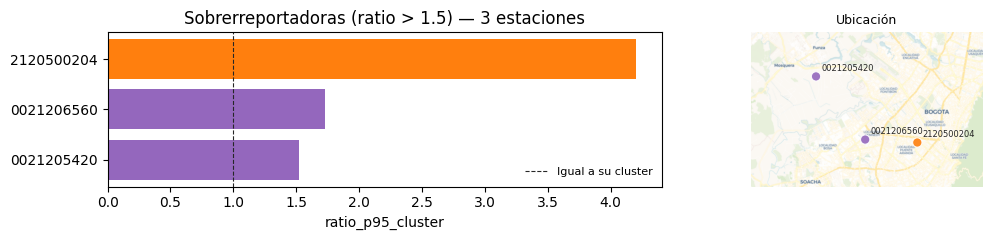

,codigo,nombre,cluster_geografico,ratio_p95_cluster
55,0021205420,TIBAITATA [21205420],5,1.52
57,0021206560,INEM KENNEDY [21206560],5,1.73
13,2120500204,IDEAM PUENTE ARANDA [2120500204],2,4.20


In [30]:
# Visualizando sobrereportadoras + mapa de ubicación
fig, (ax_barras, ax_mapa) = plt.subplots(1, 2, figsize=(11, 0.5 * len(sobrerreportadoras) + 1),
                                          gridspec_kw={'width_ratios': [1.3, 1]})

# --- Barras ---
colores_barras = sobrerreportadoras['cluster_geografico'].map(colores_cluster)
ax_barras.barh(sobrerreportadoras['codigo'], sobrerreportadoras['ratio_p95_cluster'], color=colores_barras)
ax_barras.axvline(1, color='#262626', lw=0.8, linestyle='--', label='Igual a su cluster')
ax_barras.set_xlabel('ratio_p95_cluster')
ax_barras.set_title(f'Sobrerreportadoras (ratio > {umbral_outlier}) — {len(sobrerreportadoras)} estaciones')
ax_barras.legend(fontsize=8, frameon=False)

# --- Mapa, solo estas 4 estaciones ---
gdf_sobrerreportadoras = gpd.GeoDataFrame(
    sobrerreportadoras,
    geometry=[Point(xy) for xy in zip(sobrerreportadoras['longitud'], sobrerreportadoras['latitud'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)

gdf_sobrerreportadoras['color_cluster'] = gdf_sobrerreportadoras['cluster_geografico'].map(colores_cluster)
gdf_sobrerreportadoras.plot(ax=ax_mapa, color=gdf_sobrerreportadoras['color_cluster'],
                             markersize=45, alpha=0.9, zorder=3, edgecolor='white', linewidth=0.8)

for _, fila in sobrerreportadoras.iterrows():
    punto = gpd.GeoSeries([Point(fila['longitud'], fila['latitud'])], crs='EPSG:4326').to_crs(epsg=3857)
    ax_mapa.annotate(fila['codigo'], (punto.x.iloc[0], punto.y.iloc[0]),
                      fontsize=6, xytext=(4, 4), textcoords='offset points', color='#262626')

# Margen alrededor de los puntos, para que no queden pegados al borde del mapa
xs = gdf_sobrerreportadoras.geometry.x
ys = gdf_sobrerreportadoras.geometry.y
margen_x = (xs.max() - xs.min()) * 0.6 + 500
margen_y = (ys.max() - ys.min()) * 0.6 + 500
ax_mapa.set_xlim(xs.min() - margen_x, xs.max() + margen_x)
ax_mapa.set_ylim(ys.min() - margen_y, ys.max() + margen_y)

ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.Voyager, attribution=False)
ax_mapa.set_title('Ubicación', fontsize=9)
ax_mapa.set_axis_off()

plt.tight_layout()
plt.show()

display(sobrerreportadoras[['codigo', 'nombre', 'cluster_geografico', 'ratio_p95_cluster']])

#### 4.4.1 IDEAM Puente Aranda, `2120500204` 

El perfil resumen ubicó a esta estación como la más extrema de la red en `ratio_p95_cluster` (5.13) y con un segundo valor histórico casi igual al máximo (`ratio_max_segundo_max` = 1.14) — a diferencia de un pico aislado, esto señalaba múltiples días extremos, no uno solo.

**El análisis por temporada (ciclo completo 2024-2025, no solo MAM/SON) confirmó que el problema no está acotado a un evento puntual:** la estación aparece por encima de su cluster geográfico (2) en 4 de las 8 temporadas del ciclo — `JJA_24`, `DEF_25` (el bloque más extremo, incluye el máximo histórico de 651.6 mm el 2025-01-22), `MAM_25`, y `SON_25` en P95. Solo `SON_24` se comporta de forma normal frente al resto del cluster; `DEF_24` y `MAM_24` tienen cobertura insuficiente (0% y 27.2% respectivamente) para evaluar.

In [31]:
# Función tabla_extremos_clusters
def tabla_extremos_cluster(cluster_id, codigo_objetivo, bandas):
    """Máximo y P95 por estación del cluster, para cada temporada de `bandas`."""
    codigos_cluster = df_temporadas.loc[df_temporadas['cluster_geografico'] == cluster_id, 'codigo'].tolist()

    filas = []
    for codigo in codigos_cluster:
        fila = {'codigo': codigo, 'objetivo': codigo == codigo_objetivo}
        for nombre, (ini, fin) in bandas.items():
            rango = pd.date_range(ini, fin, freq='D', inclusive='left')
            serie_ventana = series_diarias[codigo].reindex(rango)
            fila[f'{nombre}_max'] = serie_ventana.max()
            fila[f'{nombre}_p95'] = serie_ventana.quantile(0.95)
        filas.append(fila)

    return pd.DataFrame(filas).sort_values('objetivo', ascending=False).round(1)

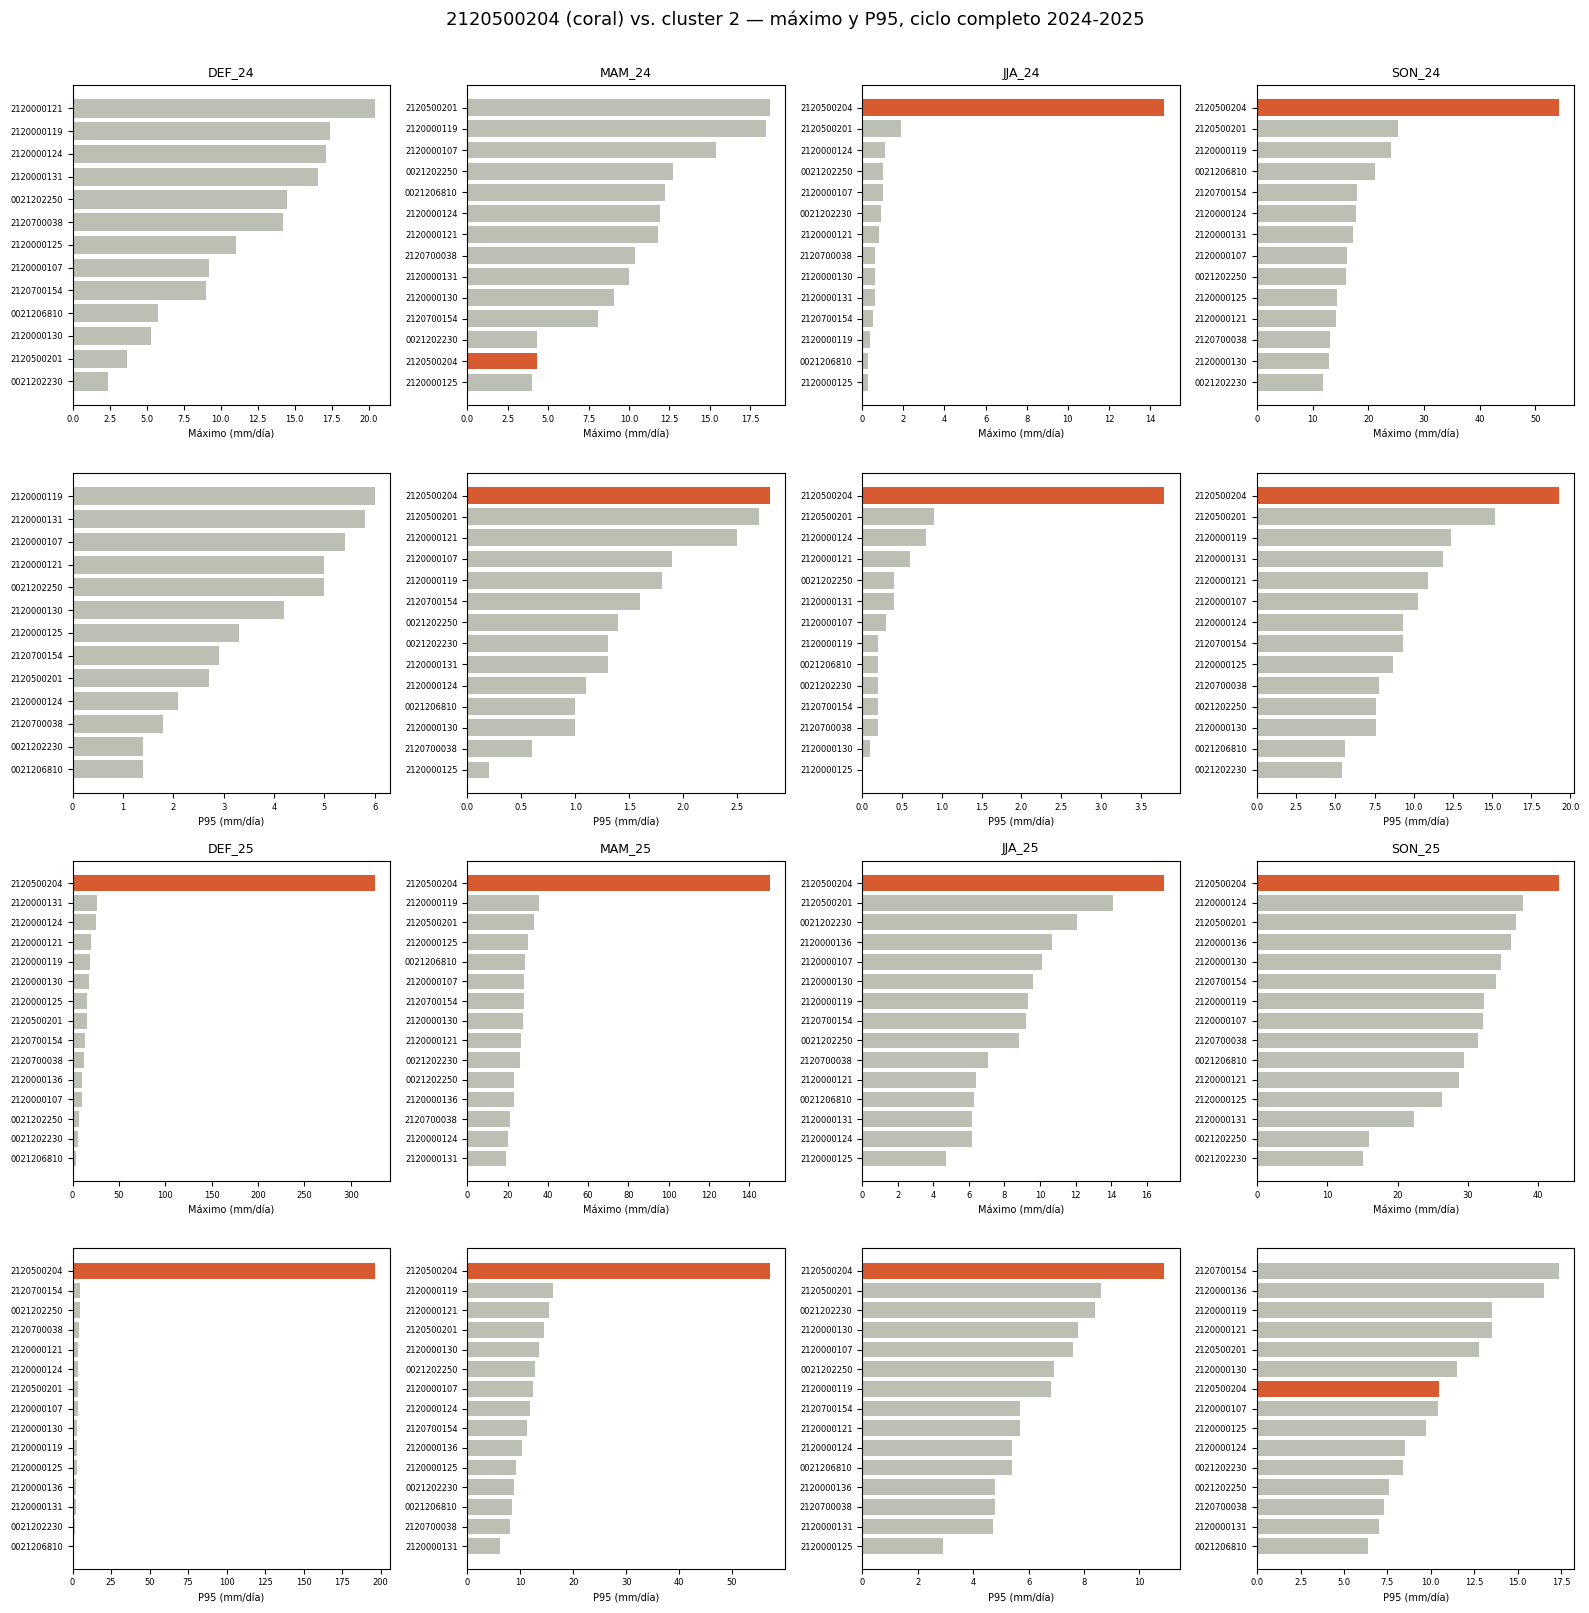

In [32]:
# Zoom sobre 2120500204
codigo_objetivo_pa = '2120500204'
cluster_pa = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo_pa, 'cluster_geografico'].values[0]

tabla_pa_completa = tabla_extremos_cluster(cluster_id=cluster_pa, codigo_objetivo=codigo_objetivo_pa, bandas=BANDAS)

temporadas_orden = list(BANDAS.keys())
metricas = [('max', 'Máximo (mm/día)'), ('p95', 'P95 (mm/día)')]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for bloque in range(2):
    temporadas_bloque = temporadas_orden[bloque * 4:(bloque + 1) * 4]
    for fila_idx, (sufijo, etiqueta_x) in enumerate(metricas):
        fila_grilla = bloque * 2 + fila_idx
        for col_idx, temporada in enumerate(temporadas_bloque):
            ax = axes[fila_grilla, col_idx]
            columna = f'{temporada}_{sufijo}'
            datos = tabla_pa_completa[['codigo', columna, 'objetivo']].dropna(subset=[columna]).sort_values(columna, ascending=True)
            colores = ['#D85A30' if obj else '#BBBFB4' for obj in datos['objetivo']]

            ax.barh(datos['codigo'], datos[columna], color=colores)
            ax.tick_params(labelsize=6)
            ax.set_xlabel(etiqueta_x, fontsize=7)

            if fila_idx == 0:
                ax.set_title(temporada, fontsize=9)

fig.suptitle(f'{codigo_objetivo_pa} (coral) vs. cluster {cluster_pa} — máximo y P95, ciclo completo 2024-2025', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

**A diferencia de `0021205791` (El Dorado), no se identificó un mecanismo físico de contaminación confirmado.** La estación está ubicada en Puente Aranda, una localidad de uso industrial denso en Bogotá — un entorno donde la vibración mecánica (la misma hipótesis que explicó a El Dorado) es plausible, pero el catálogo no ofrece el nivel de detalle de ubicación necesario para confirmarlo con la misma certeza. Su cadencia de reporte es inestable a través de las temporadas (29.6 → 6.3 → 12.0 → 10.7 min), consistente con comportamiento de instrumento irregular, pero sin la firma sub-horaria específica (picos regulares no convectivos) que sí se verificó directamente para El Dorado.

**Decisión: se excluye del dataset final**, con un estándar de evidencia distinto al de El Dorado — no por mecanismo físico confirmado, sino por anomalía estadística sistemática y recurrente en la mayoría de las temporadas del ciclo, sin explicación climática ni orográfica plausible (altitud de 2559 m, dentro del rango normal de la red).

##### Criterio #3, Anomalía no explicada (-excluir-)

Se excluye una estación cuando presenta anomalía estadística sistemática (desviación marcada frente a su cluster geográfico, en cualquier dirección — sobre o subreporte) recurrente en la mayoría de las temporadas del ciclo anual, sin mecanismo físico de contaminación confirmado ni explicación climática/orográfica alternativa disponible.

Este criterio exige un estándar de evidencia menor que el Criterio #2 (no requiere causa identificada) y debe documentarse explícitamente como tal — la decisión se apoya en el peso acumulado de la evidencia estadística, no en una causa verificada.

#### ELIMINAR 4.4.2 Nueva Generación, `0021206600`

El perfil resumen mostró un patrón errático, distinto a las anomalías unidireccionales de `0021205791` y `2120500204`: la estación oscila entre extremos opuestos según la temporada, en vez de mantenerse sistemáticamente alta o baja.

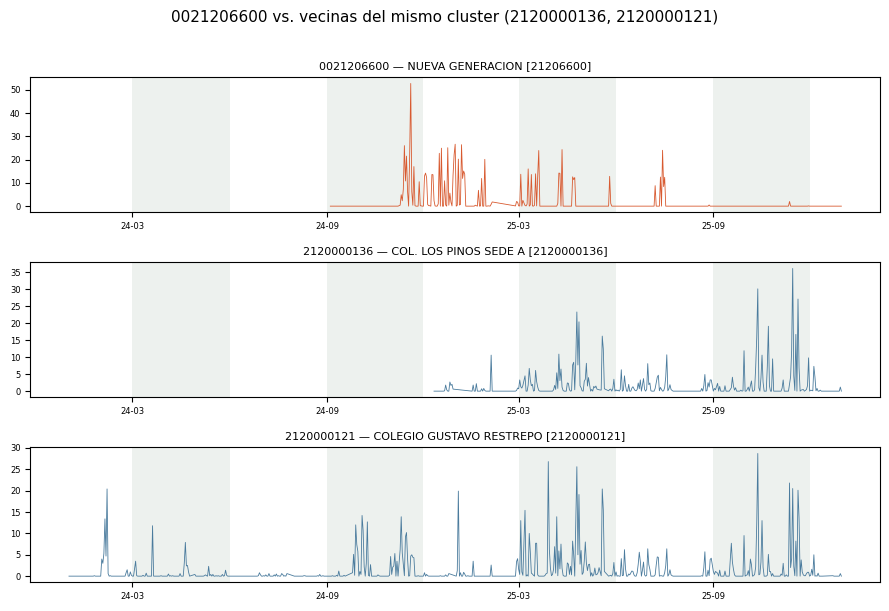

In [33]:
# Zoom en estación 0021206600
codigos_comparar = ['0021206600', '2120000136', '2120000121']

fig, axes = plt.subplots(len(codigos_comparar), 1, figsize=(9, 2 * len(codigos_comparar)), sharex=True)

for ax, codigo in zip(axes, codigos_comparar):
    serie = series_diarias[codigo]
    sombrear_temporada_humeda(ax, 2024, 2025)
    color = '#D85A30' if codigo == '0021206600' else '#4A7B9D'
    ax.plot(serie.index, serie.values, lw=0.6, color=color, zorder=2)
    nombre = df_temporadas.loc[df_temporadas['codigo'] == codigo, 'nombre'].values[0]
    ax.set_title(f'{codigo} — {nombre}', fontsize=8)
    ax.tick_params(labelsize=6)

locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter('%y-%m')
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(labelbottom=True, labelsize=6)

fig.suptitle('0021206600 vs. vecinas del mismo cluster (2120000136, 2120000121)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

**Contra sus dos vecinas más cercanas del cluster geográfico (3)**, el recorrido temporada por temporada confirma esa inestabilidad:

- **DEF_24-JJA_24**: plana — hueco de cobertura consistente con el grupo de reactivación tardía (tecnología Convencional).
- **SON_24**: arranca con registro tardío y anómalo, pero los valores que sí se registran "normales" hacia el final de la ventana coinciden razonablemente con las dos vecinas — sugiere una corrección de instrumento a mitad de temporada, no un problema persistente en esta ventana.
- **DEF_25**: claramente por encima de sus dos vecinas — el bloque más denso de toda su serie, con una magnitud que no corresponde a un DEF típico de la zona.
- **MAM_25**: por debajo de lo esperado frente a sus vecinas, con la señal decreciendo progresivamente hacia el final de la ventana.
- **SON_25**: prácticamente en cero, mientras ambas vecinas muestran actividad normal (picos claros de hasta ~30-100 mm en la misma ventana) — descarta que sea una temporada seca real en la zona. Cadencia confirmada en 10.4 min, dentro de su rango histórico normal: el instrumento sigue transmitiendo con normalidad, pero el sensor de precipitación no está detectando lluvia — consistente con un balancín físicamente obstruido, no con una falla de telemetría.

**Decisión: se excluye del dataset final**, bajo el Criterio #3 (anomalía estadística no explicada), con la salvedad de que el estándar de evidencia no es uniforme dentro del propio caso — para SON_25 específicamente hay una hipótesis mecánica razonable (sensor atascado), mientras que DEF_25 y MAM_25 quedan sin explicación identificada, solo con el peso de la evidencia estadística frente a sus vecinas.

#### 4.4.2 INEM Kennedy, `0021206560`

El desglose por temporada, contra los valores absolutos de las 7 vecinas de cluster, muestra que la mayoría de las temporadas marcadas como "fuera de rango" lo están por un margen mínimo: `MAM_25` (+3% sobre el máximo de vecinas) y `JJA_25` (+9%) están dentro de lo que razonablemente podría ser ruido de estimación del P95. `JJA_24` tiene baja confiabilidad por magnitudes diminutas de temporada seca.

Solo `SON_24` (17.3 frente a un máximo de vecinas de 13.9, +24%) constituye una desviación real y sustancial — pero es una única temporada, no un patrón recurrente.

Mención aparte tiene `JJA_24`, el cual muestra un exceso relativo extremo (+829%), pero no es confiable: tanto el objetivo (6.5 mm) como el rango de vecinas (0.1-0.7 mm) son magnitudes casi nulas — consistente con la recuperación progresiva de la red documentada en 4.2 — y con denominadores tan pequeños, el porcentaje de exceso deja de ser interpretable independientemente de la causa.

**Decisión: se conserva en el dataset final.** No alcanza el estándar del Criterio #3 (recurrencia con magnitud real en la mayoría de las temporadas) — solo una temporada muestra una anomalía de peso genuino. Se documenta `SON_24` como temporada puntual de calidad cuestionable, sin excluir la estación.

In [36]:
# Zoom sobre estación INEM Kennedy
codigo_objetivo = '0021206560'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

tabla_560 = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

n_vecinas = len(tabla_560) - 1
umbral_magnitud_minima = 2.0  # mm — por debajo de esto, el % de exceso no es confiable (denominador casi cero)

columnas_p95 = ['codigo', 'objetivo'] + [c for c in tabla_560.columns if c.endswith('_p95')]
tabla_p95 = tabla_560[columnas_p95].sort_values('objetivo', ascending=False)
print(f"=== P95 por temporada — objetivo vs. las {n_vecinas} vecinas ===")
display(tabla_p95)

print("\n=== ¿En qué temporadas el objetivo se sale del rango de sus vecinas, y por cuánto? ===")
resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_560.loc[~tabla_560['objetivo'], col].dropna()
    objetivo_valor = tabla_560.loc[tabla_560['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min

    if objetivo_valor > rango_max:
        exceso_abs = objetivo_valor - rango_max
        exceso_rel = exceso_abs / rango_max if rango_max > 0 else np.nan
    elif objetivo_valor < rango_min:
        exceso_abs = objetivo_valor - rango_min
        exceso_rel = exceso_abs / rango_min if rango_min > 0 else np.nan
    else:
        exceso_abs = 0.0
        exceso_rel = 0.0

    resumen_rango.append({
        'temporada': temporada,
        'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1),
        'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango,
        'exceso_abs': round(exceso_abs, 1),
        'exceso_rel_%': round(exceso_rel * 100, 1) if pd.notna(exceso_rel) else np.nan,
        'confiable': rango_max >= umbral_magnitud_minima,
    })

df_resumen_rango = pd.DataFrame(resumen_rango).sort_values('exceso_rel_%', ascending=False, na_position='last')
display(df_resumen_rango)

n_confiables_fuera_rango = ((df_resumen_rango['fuera_de_rango']) & (df_resumen_rango['confiable'])).sum()
print(f"\n{n_confiables_fuera_rango} temporada(s) fuera de rango Y con magnitud confiable (≥{umbral_magnitud_minima} mm)")

=== P95 por temporada — objetivo vs. las 7 vecinas ===


,codigo,objetivo,DEF_24_p95,MAM_24_p95,JJA_24_p95,SON_24_p95,DEF_25_p95,MAM_25_p95,JJA_25_p95,SON_25_p95
6,0021206560,True,NaN,NaN,6.5,17.3,2.3,19.7,11.5,9.4
0,2120000122,False,2.7,1.0,0.6,9.1,2.4,15.9,5.2,8.6
1,2120000173,False,1.6,1.6,0.4,9.9,3.1,19.1,5.5,13.6
2,2120000123,False,2.9,0.8,0.7,10.9,3.2,10.9,5.3,11.8
3,2120000175,False,1.5,2.1,0.7,9.7,1.4,13.0,5.2,10.8
4,0021206780,False,6.1,1.1,0.1,6.9,1.8,8.3,6.5,11.7
5,0021205420,False,NaN,NaN,NaN,13.9,3.5,16.8,10.5,11.1
7,0021208480,False,2.0,0.7,0.6,10.2,3.3,11.0,4.9,11.2



=== ¿En qué temporadas el objetivo se sale del rango de sus vecinas, y por cuánto? ===


,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_abs,exceso_rel_%,confiable
0,JJA_24,6.5,0.1,0.7,True,5.8,828.6,False
1,SON_24,17.3,6.9,13.9,True,3.4,24.5,True
4,JJA_25,11.5,4.9,10.5,True,1.0,9.5,True
3,MAM_25,19.7,8.3,19.1,True,0.6,3.1,True
2,DEF_25,2.3,1.4,3.5,False,0.0,0.0,True
5,SON_25,9.4,8.6,13.6,False,0.0,0.0,True



3 temporada(s) fuera de rango Y con magnitud confiable (≥2.0 mm)


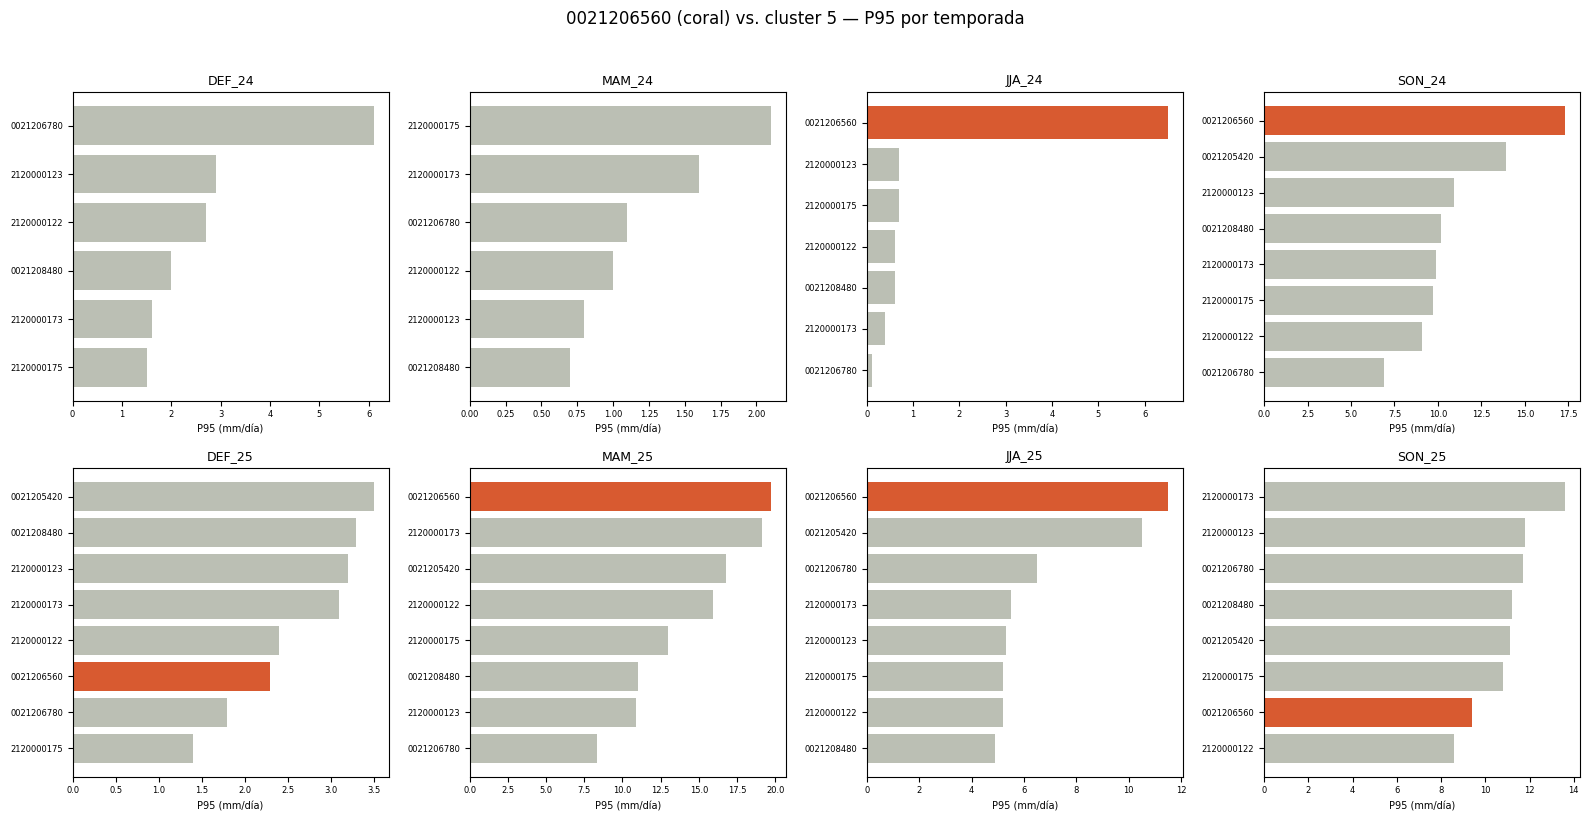

In [37]:
# Estación INEM Kennedy vs sus vecinas
temporadas_con_dato = [t for t in BANDAS.keys() if not tabla_560[f'{t}_p95'].isna().all()]
n_cols = 4
n_rows = -(-len(temporadas_con_dato) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, temporada in enumerate(temporadas_con_dato):
    ax = axes[i]
    col = f'{temporada}_p95'
    datos = tabla_560[['codigo', col, 'objetivo']].dropna(subset=[col]).sort_values(col, ascending=True)
    colores = ['#D85A30' if obj else '#BBBFB4' for obj in datos['objetivo']]
    ax.barh(datos['codigo'], datos[col], color=colores)
    ax.set_title(temporada, fontsize=9)
    ax.tick_params(labelsize=6)
    ax.set_xlabel('P95 (mm/día)', fontsize=7)

for j in range(len(temporadas_con_dato), len(axes)):
    axes[j].axis('off')

fig.suptitle(f'{codigo_objetivo} (coral) vs. cluster {cluster_id} — P95 por temporada', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### 4.4.3 Tibaitatá, `0021205420`

El ratio de 1.52 lo ubica apenas sobre el umbral de sobrerreporte, pero el desglose por temporada no sostiene un patrón: de seis temporadas con dato, solo DEF_25 queda fuera del rango de sus 7 vecinas, y por un margen de 6.1% — comparable al margen mínimo que ya se documentó como ruido de estimación en el caso de INEM Kennedy (Sección 4.4.2). El máximo histórico de la estación (35.4mm, 2024-11-19) coincide con un evento regional que también elevó a sus vecinas ese mismo día (rango 5.6-16.7mm), descartando un pico aislado. Altitud (2543m) dentro de rango normal del cluster.

**Se conserva en el dataset final** — no alcanza el estándar del Criterio #3.

In [39]:
codigo_objetivo = '0021205420'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_420 = df_temporadas[df_temporadas['codigo'] == codigo_objetivo][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'DEF_25_cadencia_media', 'MAM_25_cadencia_media']
]
display(perfil_420)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global,MAM_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media
55,0021205420,TIBAITATA [21205420],5,"Automática con Telemetría, Convencional",2543.0,0.0,0.0,0.0,0.275,1.52,1.331,2024-11-19,35.4,NaN,14.6,14.2,12.6


In [41]:
# Zoom sobre la estación Tibaitatá
tabla_420 = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

n_vecinas = len(tabla_420) - 1
print(f"=== P95 por temporada — objetivo vs. las {n_vecinas} vecinas ===")

resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_420.loc[~tabla_420['objetivo'], col].dropna()
    objetivo_valor = tabla_420.loc[tabla_420['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min
    exceso_abs = objetivo_valor - rango_max if objetivo_valor > rango_max else (objetivo_valor - rango_min if objetivo_valor < rango_min else 0.0)
    exceso_rel = exceso_abs / rango_max if objetivo_valor > rango_max and rango_max > 0 else (exceso_abs / rango_min if objetivo_valor < rango_min and rango_min > 0 else 0.0)
    resumen_rango.append({
        'temporada': temporada, 'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1), 'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango, 'exceso_rel_%': round(exceso_rel * 100, 1),
        'confiable': rango_max >= umbral_magnitud_minima,
    })
display(pd.DataFrame(resumen_rango).sort_values('exceso_rel_%', ascending=False))

# Altitud de las vecinas, para confirmar que el criterio de 300m se respetó
vecinas_codigos = tabla_420.loc[~tabla_420['objetivo'], 'codigo'].tolist()
print("\nAltitud del objetivo y sus vecinas:")
display(df_temporadas[df_temporadas['codigo'].isin([codigo_objetivo] + vecinas_codigos)][['codigo', 'nombre', 'altitud']])

# Vecinas en la fecha del pico
print(f"\nVecinas en {perfil_420['fecha_max_global'].values[0]}:")
for codigo in vecinas_codigos:
    valor = series_diarias[codigo].get(pd.Timestamp(perfil_420['fecha_max_global'].values[0]), 'sin dato')
    print(f"  {codigo}: {valor}")

=== P95 por temporada — objetivo vs. las 7 vecinas ===


,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_rel_%,confiable
1,DEF_25,3.5,1.4,3.3,True,6.1,True
0,SON_24,13.9,6.9,17.3,False,0.0,True
2,MAM_25,16.8,8.3,19.7,False,0.0,True
3,JJA_25,10.5,4.9,11.5,False,0.0,True
4,SON_25,11.1,8.6,13.6,False,0.0,True



Altitud del objetivo y sus vecinas:


,codigo,nombre,altitud
1,2120000122,COLEGIO INEM FRANCISCO DE PAULA SANTANDER (IED...,2557.0
6,2120000173,COLEGIO CARLO FEDERICI (IED) [2120000173],2577.0
7,2120000123,COLEGIO LA CHUCUA [2120000123],2562.0
8,2120000175,COLEGIO LA FELICIDAD (IED) [2120000175],2584.0
30,0021206780,LA INDEPENDENCI - AUT [21206780],2548.0
55,0021205420,TIBAITATA [21205420],2543.0
57,0021206560,INEM KENNEDY [21206560],2557.0
60,0021208480,KENNEDY - AUT [21208480],2555.0



Vecinas en 2024-11-19T00:00:00.000000000:
  2120000122: 10.0
  2120000173: 5.6000000000000005
  2120000123: 15.1
  2120000175: 6.1000000000000005
  0021206780: 7.800000000000001
  0021206560: 16.7
  0021208480: 8.3


---

Recalculando estadísticos de cluster, dada la exclusión de dos estaciones:

In [42]:
estaciones_excluidas = ['2120500204']
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")

df_temporadas = df_temporadas[df_temporadas['codigo'].isin(codigos_finales)].copy()

64 estaciones en el dataset final (de 65)


In [43]:
# Recálculo de pool tras exclusión de Puente Aranda
def p95_estacion(codigo):
    return series_diarias[codigo].quantile(0.95) if codigo in series_diarias else np.nan

clusters_afectados = df_temporadas.loc[
    df_temporadas['codigo'].isin(
        pd.concat([
            df_temporadas[df_temporadas['cluster_geografico'].isin(
                df_temporadas['cluster_geografico'].unique()
            )]['codigo']
        ])
    ), 'cluster_geografico'
].unique()

# Más simple y correcto: recalcular TODOS los clusters, sin adivinar cuáles cambiaron
for cluster_id, grupo in df_temporadas.groupby('cluster_geografico'):
    codigos_cluster = grupo['codigo'].tolist()
    for codigo in codigos_cluster:
        resto = [c for c in codigos_cluster if c != codigo]
        nuevo_prom = np.nanmean([p95_estacion(c) for c in resto]) if resto else np.nan
        df_temporadas.loc[df_temporadas['codigo'] == codigo, 'p95_cluster_prom'] = nuevo_prom
        df_temporadas.loc[df_temporadas['codigo'] == codigo, 'ratio_p95_cluster'] = round(
            p95_estacion(codigo) / nuevo_prom, 2
        ) if nuevo_prom > 0 else np.nan

print(f"Pool recalculado — {len(df_temporadas)} estaciones")

Pool recalculado — 64 estaciones


In [44]:
# Definición de sobre y subreportadoras
umbral_outlier = 1.5  # ratio por encima o por debajo de este valor respecto a su cluster

outliers = df_temporadas[
    (df_temporadas['ratio_p95_cluster'] > umbral_outlier) |
    (df_temporadas['ratio_p95_cluster'] < 1 / umbral_outlier)
].copy()

print(f"{len(outliers)} estación(es) etiquetada(s) como outlier (ratio > {umbral_outlier} o < {1/umbral_outlier:.2f})")

sobrerreportadoras = outliers[outliers['ratio_p95_cluster'] > umbral_outlier].sort_values('ratio_p95_cluster', ascending=True)
subreportadoras = outliers[outliers['ratio_p95_cluster'] < 1 / umbral_outlier].sort_values('ratio_p95_cluster', ascending=False)

5 estación(es) etiquetada(s) como outlier (ratio > 1.5 o < 0.67)


### 4.5 Subreportadoras (ratio_p95_cluster < 0.67)

Mismo procedimiento que en 4.4, aplicado a las estaciones cuyo nivel general de precipitación cae por debajo de dos tercios del promedio de su cluster geográfico — el subreporte es tan anómalo como el sobrerreporte, aunque menos llamativo en magnitud absoluta cuando la base de comparación ya es baja (ver nota sobre escala en la introducción de esta sección de resultados).

Con el pool recalculado tras la exclusión de 4.4 (`Puente Aranda`), el número de candidatas bajó de 9 a 2 — la mayoría de las estaciones que parecían subreportar lo hacían por comparación contra un promedio de cluster inflado por Puente Aranda, no por un déficit real propio. Es el mismo fenómeno de enmascaramiento(*masking*) que motiva recalcular el pool después de cada exclusión.

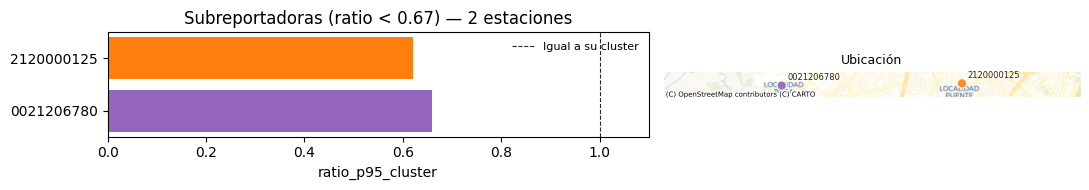

,codigo,nombre,cluster_geografico,ratio_p95_cluster
30,0021206780,LA INDEPENDENCI - AUT [21206780],5,0.66
26,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,2,0.62


In [46]:
# Visualizando subreportadoras + mapa de ubicación
fig, (ax_barras, ax_mapa) = plt.subplots(1, 2, figsize=(11, 0.5 * len(subreportadoras) + 1),
                                          gridspec_kw={'width_ratios': [1.3, 1]})

# --- Barras (igual que antes) ---
colores_barras = subreportadoras['cluster_geografico'].map(colores_cluster)
ax_barras.barh(subreportadoras['codigo'], subreportadoras['ratio_p95_cluster'], color=colores_barras)
ax_barras.axvline(1, color='#262626', lw=0.8, linestyle='--', label='Igual a su cluster')
ax_barras.set_xlim(0, 1.1)
ax_barras.set_xlabel('ratio_p95_cluster')
ax_barras.set_title(f'Subreportadoras (ratio < {1/umbral_outlier:.2f}) — {len(subreportadoras)} estaciones')
ax_barras.legend(fontsize=8, frameon=False)

# --- Mapa, solo estas estaciones ---
gdf_subreportadoras = gpd.GeoDataFrame(
    subreportadoras,
    geometry=[Point(xy) for xy in zip(subreportadoras['longitud'], subreportadoras['latitud'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)

gdf_subreportadoras['color_cluster'] = gdf_subreportadoras['cluster_geografico'].map(colores_cluster)
gdf_subreportadoras.plot(ax=ax_mapa, color=gdf_subreportadoras['color_cluster'],
                          markersize=45, alpha=0.9, zorder=3, edgecolor='white', linewidth=0.8)

for _, fila in subreportadoras.iterrows():
    punto = gpd.GeoSeries([Point(fila['longitud'], fila['latitud'])], crs='EPSG:4326').to_crs(epsg=3857)
    ax_mapa.annotate(fila['codigo'], (punto.x.iloc[0], punto.y.iloc[0]),
                      fontsize=6, xytext=(4, 4), textcoords='offset points', color='#262626')

xs = gdf_subreportadoras.geometry.x
ys = gdf_subreportadoras.geometry.y
margen_x = (xs.max() - xs.min()) * 0.6 + 500
margen_y = (ys.max() - ys.min()) * 0.6 + 500
ax_mapa.set_xlim(xs.min() - margen_x, xs.max() + margen_x)
ax_mapa.set_ylim(ys.min() - margen_y, ys.max() + margen_y)

ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.Voyager, attribution_size=5)
ax_mapa.set_title('Ubicación', fontsize=9)
ax_mapa.set_axis_off()

plt.tight_layout()
plt.show()

display(subreportadoras[['codigo', 'nombre', 'cluster_geografico', 'ratio_p95_cluster']])

#### 4.5.1 Colegio Sorrento, `2120000125`

Con ratio 0.62, el desglose por temporada muestra una sola temporada con déficit confiable (`JJA_25`, -38.3%); las otras dos marcadas fuera de rango (`MAM_24`, `JJA_24`) se descartan por baja confiabilidad de temporada seca. A diferencia de La Independencia (Sección 4.5.2), acá la cobertura propia en `JJA_25` (68.5%) es la más baja de las 14 estaciones del cluster, aunque por un margen leve (3 puntos por debajo del resto) — no permite descartar con la misma confianza que el déficit sea señal real y no parcialmente artefacto de menor cobertura. Con una sola temporada de evidencia, y esa evidencia sin poder aislarse limpiamente de la cobertura, no alcanza el estándar del Criterio #3.

**Se conserva en el dataset final.**

In [55]:
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == '2120000125', 'cluster_geografico'].values[0]
df_temporadas.loc[df_temporadas['cluster_geografico'] == cluster_id,
                   ['codigo', 'nombre', 'JJA_25_mean_dias_con_dato']].sort_values('JJA_25_mean_dias_con_dato')

,codigo,nombre,JJA_25_mean_dias_con_dato
26,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,0.685
14,2120500201,VITELMA [2120500201],0.717
27,2120000121,COLEGIO GUSTAVO RESTREPO [2120000121],0.717
24,2120000124,COLEGIO RAFAEL URIBE [2120000124],0.717
65,0021202250,DOÑA JUANA - AUT [21202250],0.717
61,0021206810,SAN BENITO - AUT [21206810],0.717
22,2120000130,COLEGIO PAULO FREIRE [2120000130],0.728
19,2120700038,SAN FRANCISCO - AUT [2120700038],0.728
33,2120000136,COL. LOS PINOS SEDE A [2120000136],0.728
28,2120000131,COLEGIO ANTONIO GARCIA [2120000131],0.728


In [54]:
codigo_objetivo = '2120000125'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_125 = df_temporadas[df_temporadas['codigo'] == codigo_objetivo][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
         'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
         'JJA_25_mean_dias_con_dato',
         'ratio_p95_cluster', 'ratio_max_segundo_max',
         'fecha_max_global', 'precip_max_global',
         'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'DEF_25_cadencia_media', 'MAM_25_cadencia_media', 'JJA_25_cadencia_media']
]
display(perfil_125)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,JJA_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global,MAM_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media,JJA_25_cadencia_media
26,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,2,Automática con Telemetría,2561.0,0.505,0.848,0.587,0.857,0.685,0.62,1.144,2025-05-20,30.1,18.3,3.6,2.4,2.4,3.6


In [51]:
tabla_125 = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

n_vecinas = len(tabla_125) - 1
print(f"=== P95 por temporada — objetivo vs. las {n_vecinas} vecinas ===")

resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_125.loc[~tabla_125['objetivo'], col].dropna()
    objetivo_valor = tabla_125.loc[tabla_125['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min
    if objetivo_valor > rango_max:
        exceso_abs = objetivo_valor - rango_max
        exceso_rel = exceso_abs / rango_max if rango_max > 0 else np.nan
    elif objetivo_valor < rango_min:
        exceso_abs = objetivo_valor - rango_min
        exceso_rel = exceso_abs / rango_min if rango_min > 0 else np.nan
    else:
        exceso_abs, exceso_rel = 0.0, 0.0
    resumen_rango.append({
        'temporada': temporada, 'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1), 'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango,
        'exceso_rel_%': round(exceso_rel * 100, 1) if pd.notna(exceso_rel) else np.nan,
        'confiable': rango_max >= umbral_magnitud_minima if objetivo_valor > rango_max else rango_min >= umbral_magnitud_minima,
    })
display(pd.DataFrame(resumen_rango))

=== P95 por temporada — objetivo vs. las 13 vecinas ===


,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_rel_%,confiable
0,DEF_24,3.3,1.4,6.0,False,0.0,False
1,MAM_24,0.2,0.6,2.7,True,-66.7,False
2,JJA_24,0.0,0.1,0.9,True,-100.0,False
3,SON_24,8.7,5.4,15.2,False,0.0,True
4,DEF_25,2.8,0.6,4.8,False,0.0,False
5,MAM_25,9.1,6.1,16.2,False,0.0,True
6,JJA_25,2.9,4.7,8.6,True,-38.3,True
7,SON_25,9.7,6.4,17.4,False,0.0,True


#### 4.5.2 La Independencia, `0021206780`

El desglose por temporada, contra el rango real de sus 7 vecinas del cluster 5, muestra subreporte confiable y consistente en dos temporadas de magnitud sustancial: `SON_24` (6.9 mm frente a un rango de vecinas de 9.1-17.3, -24%) y `MAM_25` (8.3 mm frente a 10.9-19.7, -24%). `JJA_24` (-75%) se descarta por baja confiabilidad (magnitudes diminutas de temporada seca); `DEF_24` muestra exceso en dirección contraria (+110%), pero con la cobertura más baja de la propia estación (44%) — no se cuenta como evidencia en ninguna dirección.

**Se descartó explícitamente una hipótesis alternativa** antes de confiar en las dos temporadas de subreporte: que el déficit reflejara mala cobertura propia (menos días de dato que sus vecinas), no un nivel real más bajo. La estación tiene, de hecho, la cobertura más alta o empatada del cluster en ambas temporadas (`SON_24`: 0.857, la más alta de las 8; `MAM_25`: 1.5, empatada con la más alta) — el déficit no se explica por falta de datos.

**Decisión: se excluye del dataset final**, bajo el Criterio #3 — subreporte recurrente y confiable en 2 de las 8 temporadas, con magnitud suficiente para sostener la lectura, cobertura propia descartada como explicación  alternativa, y sin mecanismo físico identificado.

In [53]:
codigo_objetivo = '0021206780'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_780 = df_temporadas[df_temporadas['codigo'] == codigo_objetivo][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'JJA_25_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'DEF_25_cadencia_media', 'MAM_25_cadencia_media', 'JJA_25_cadencia_media']
]
display(perfil_780)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,JJA_25_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global,MAM_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media,JJA_25_cadencia_media
30,0021206780,LA INDEPENDENCI - AUT [21206780],5,Automática con Telemetría,2548.0,0.44,0.87,0.696,0.857,0.728,0.66,1.376,2025-04-27,29.3,5.9,2.8,2.2,1.5,2.1


In [48]:
tabla_780 = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

n_vecinas = len(tabla_780) - 1
print(f"=== P95 por temporada — objetivo vs. las {n_vecinas} vecinas ===")

resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_780.loc[~tabla_780['objetivo'], col].dropna()
    objetivo_valor = tabla_780.loc[tabla_780['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min
    if objetivo_valor > rango_max:
        exceso_abs = objetivo_valor - rango_max
        exceso_rel = exceso_abs / rango_max if rango_max > 0 else np.nan
    elif objetivo_valor < rango_min:
        exceso_abs = objetivo_valor - rango_min
        exceso_rel = exceso_abs / rango_min if rango_min > 0 else np.nan
    else:
        exceso_abs, exceso_rel = 0.0, 0.0
    resumen_rango.append({
        'temporada': temporada, 'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1), 'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango,
        'exceso_rel_%': round(exceso_rel * 100, 1) if pd.notna(exceso_rel) else np.nan,
        'confiable': rango_max >= umbral_magnitud_minima if objetivo_valor > rango_max else rango_min >= umbral_magnitud_minima,
    })
display(pd.DataFrame(resumen_rango))

=== P95 por temporada — objetivo vs. las 7 vecinas ===


,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_rel_%,confiable
0,DEF_24,6.1,1.5,2.9,True,110.3,True
1,MAM_24,1.1,0.7,2.1,False,0.0,False
2,JJA_24,0.1,0.4,6.5,True,-75.0,False
3,SON_24,6.9,9.1,17.3,True,-24.2,True
4,DEF_25,1.8,1.4,3.5,False,0.0,False
5,MAM_25,8.3,10.9,19.7,True,-23.9,True
6,JJA_25,6.5,4.9,11.5,False,0.0,True
7,SON_25,11.7,8.6,13.6,False,0.0,True


---
Recalculando estadísticos de cluster, dada la exclusión de una estación:

In [56]:
estaciones_excluidas = ['0021206780']
codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]
print(f"{len(codigos_finales)} estaciones en el dataset final (de {len(df_temporadas)})")

df_temporadas = df_temporadas[df_temporadas['codigo'].isin(codigos_finales)].copy()

63 estaciones en el dataset final (de 64)


In [57]:
# Recálculo de pool
for cluster_id, grupo in df_temporadas.groupby('cluster_geografico'):
    codigos_cluster = grupo['codigo'].tolist()
    for codigo in codigos_cluster:
        resto = [c for c in codigos_cluster if c != codigo]
        nuevo_prom = np.nanmean([p95_estacion(c) for c in resto]) if resto else np.nan
        df_temporadas.loc[df_temporadas['codigo'] == codigo, 'p95_cluster_prom'] = nuevo_prom
        df_temporadas.loc[df_temporadas['codigo'] == codigo, 'ratio_p95_cluster'] = round(
            p95_estacion(codigo) / nuevo_prom, 2
        ) if nuevo_prom > 0 else np.nan

print(f"Pool recalculado — {len(df_temporadas)} estaciones")

Pool recalculado — 63 estaciones


In [58]:
# Definición de sobre y subreportadoras
umbral_outlier = 1.5  # ratio por encima o por debajo de este valor respecto a su cluster

outliers = df_temporadas[
    (df_temporadas['ratio_p95_cluster'] > umbral_outlier) |
    (df_temporadas['ratio_p95_cluster'] < 1 / umbral_outlier)
].copy()

print(f"{len(outliers)} estación(es) etiquetada(s) como outlier (ratio > {umbral_outlier} o < {1/umbral_outlier:.2f})")

sobrerreportadoras = outliers[outliers['ratio_p95_cluster'] > umbral_outlier].sort_values('ratio_p95_cluster', ascending=True)
subreportadoras = outliers[outliers['ratio_p95_cluster'] < 1 / umbral_outlier].sort_values('ratio_p95_cluster', ascending=False)

3 estación(es) etiquetada(s) como outlier (ratio > 1.5 o < 0.67)


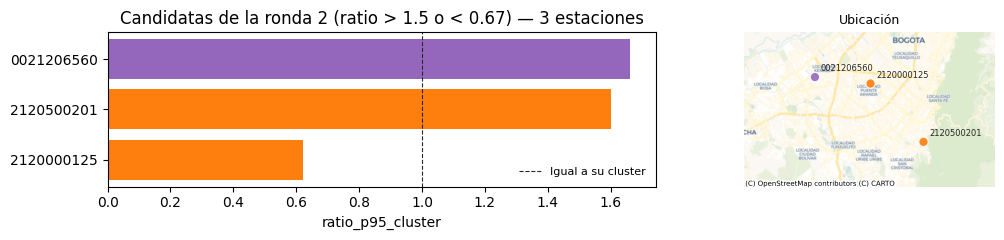

,codigo,nombre,cluster_geografico,ratio_p95_cluster
26,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,2,0.62
14,2120500201,VITELMA [2120500201],2,1.60
57,0021206560,INEM KENNEDY [21206560],5,1.66


In [59]:
# Visualizando subreportadoras y sobrereportadoras + mapa de ubicación
combinadas = pd.concat([sobrerreportadoras, subreportadoras]).sort_values('ratio_p95_cluster', ascending=True)

fig, (ax_barras, ax_mapa) = plt.subplots(1, 2, figsize=(11, 0.5 * len(combinadas) + 1),
                                          gridspec_kw={'width_ratios': [1.3, 1]})

# --- Barras: todas juntas, la línea en 1 separa visualmente sobre de sub ---
colores_barras = combinadas['cluster_geografico'].map(colores_cluster)
ax_barras.barh(combinadas['codigo'], combinadas['ratio_p95_cluster'], color=colores_barras)
ax_barras.axvline(1, color='#262626', lw=0.8, linestyle='--', label='Igual a su cluster')
ax_barras.set_xlabel('ratio_p95_cluster')
ax_barras.set_title(f'Candidatas de la ronda 2 (ratio > {umbral_outlier} o < {1/umbral_outlier:.2f}) — {len(combinadas)} estaciones')
ax_barras.legend(fontsize=8, frameon=False)

# --- Mapa, las 4 juntas ---
gdf_combinadas = gpd.GeoDataFrame(
    combinadas, geometry=[Point(xy) for xy in zip(combinadas['longitud'], combinadas['latitud'])], crs='EPSG:4326'
).to_crs(epsg=3857)
gdf_combinadas['color_cluster'] = gdf_combinadas['cluster_geografico'].map(colores_cluster)
gdf_combinadas.plot(ax=ax_mapa, color=gdf_combinadas['color_cluster'],
                     markersize=45, alpha=0.9, zorder=3, edgecolor='white', linewidth=0.8)

for _, fila in combinadas.iterrows():
    punto = gpd.GeoSeries([Point(fila['longitud'], fila['latitud'])], crs='EPSG:4326').to_crs(epsg=3857)
    ax_mapa.annotate(fila['codigo'], (punto.x.iloc[0], punto.y.iloc[0]),
                      fontsize=6, xytext=(4, 4), textcoords='offset points', color='#262626')

xs, ys = gdf_combinadas.geometry.x, gdf_combinadas.geometry.y
margen_x = (xs.max() - xs.min()) * 0.6 + 500
margen_y = (ys.max() - ys.min()) * 0.6 + 500
ax_mapa.set_xlim(xs.min() - margen_x, xs.max() + margen_x)
ax_mapa.set_ylim(ys.min() - margen_y, ys.max() + margen_y)

ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.Voyager, attribution_size=5)
ax_mapa.set_title('Ubicación', fontsize=9)
ax_mapa.set_axis_off()

plt.tight_layout()
plt.show()

display(combinadas[['codigo', 'nombre', 'cluster_geografico', 'ratio_p95_cluster']])

### 4.6 Verificación tras exclusión de `0021206780` y candidata nueva, Vitelma (`2120500201`)

Al recalcular el pool tras excluir a `0021206780` (4.5.2), el número de outliers se recalculó a 3: dos ya estaban investigadas y su conclusión se sostiene sin cambios: `2120000125` y 0021206560`.

La tercera es nueva: `2120500201` (Vitelma), que no aparecía en ninguna ronda anterior — su presencia ahora, y no antes, es consistente con el mismo efecto de enmascaramiento ya documentado en 4.5 (comparte cluster con Puente Aranda, cuya exclusión modificó el promedio de comparación de sus vecinas).

In [60]:
codigo_objetivo = '2120500201'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_201 = df_temporadas[df_temporadas['codigo'] == codigo_objetivo][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global',
     'MAM_24_cadencia_media', 'SON_24_cadencia_media', 'DEF_25_cadencia_media', 'MAM_25_cadencia_media']
]
display(perfil_201)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global,MAM_24_cadencia_media,SON_24_cadencia_media,DEF_25_cadencia_media,MAM_25_cadencia_media
14,2120500201,VITELMA [2120500201],2,Automática con Telemetría,2777.0,0.549,0.924,0.761,0.846,1.6,1.112,2025-11-15,36.8,5.2,2.1,2.2,1.5


In [61]:
tabla_201 = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

n_vecinas = len(tabla_201) - 1
print(f"=== P95 por temporada — objetivo vs. las {n_vecinas} vecinas ===")

resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_201.loc[~tabla_201['objetivo'], col].dropna()
    objetivo_valor = tabla_201.loc[tabla_201['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min
    if objetivo_valor > rango_max:
        exceso_abs = objetivo_valor - rango_max
        exceso_rel = exceso_abs / rango_max if rango_max > 0 else np.nan
    elif objetivo_valor < rango_min:
        exceso_abs = objetivo_valor - rango_min
        exceso_rel = exceso_abs / rango_min if rango_min > 0 else np.nan
    else:
        exceso_abs, exceso_rel = 0.0, 0.0
    resumen_rango.append({
        'temporada': temporada, 'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1), 'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango,
        'exceso_rel_%': round(exceso_rel * 100, 1) if pd.notna(exceso_rel) else np.nan,
        'confiable': rango_max >= umbral_magnitud_minima if objetivo_valor > rango_max else rango_min >= umbral_magnitud_minima,
    })
display(pd.DataFrame(resumen_rango))

=== P95 por temporada — objetivo vs. las 13 vecinas ===


,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_rel_%,confiable
0,DEF_24,2.7,1.4,6.0,False,0.0,False
1,MAM_24,2.7,0.2,2.5,True,8.0,True
2,JJA_24,0.9,0.0,0.8,True,12.5,False
3,SON_24,15.2,5.4,12.4,True,22.6,True
4,DEF_25,3.4,0.6,4.8,False,0.0,False
5,MAM_25,14.5,6.1,16.2,False,0.0,True
6,JJA_25,8.6,2.9,8.4,True,2.4,True
7,SON_25,12.8,6.4,17.4,False,0.0,True


El desglose por temporada, contra el rango real de sus vecinas del cluster 2, muestra que la mayoría de las temporadas marcadas como "fuera de rango" lo están por un margen mínimo, dentro de lo que razonablemente podría ser ruido de estimación: `MAM_24` (+8%), `JJA_25` (+2.4%). `JJA_24` (+12.5%) se descarta por baja confiabilidad (magnitudes diminutas de temporada seca).

Solo `SON_24` (15.2 frente a un máximo de vecinas de 12.4, +22%) constituye una desviación real y sustancial — una única temporada, no un patrón recurrente. Mismo perfil que sostuvo la conservación de `0021206560`.

**Decisión: se conserva en el dataset final.** No alcanza el estándar del Criterio #3 — solo una temporada muestra una anomalía de peso genuino. Se documenta `SON_24` como temporada puntual de calidad cuestionable, sin excluir la estación.

### 4.7  Barrido sistemático de anomalías residuales

Las secciones 4.4-4.6 investigaron candidatas que ya se habían distinguido a través de un indicador puntual (`ratio_p95_cluster` por encima o por debajo de 1.5). Esta sección cierra el ciclo con un barrido más amplio: ubicar las estaciones activas en un plano de dos ejes — `ratio_p95_cluster` (nivel general frente al cluster) y `ratio_max_segundo_max` (qué tan aislado es el día más lluvioso de la estación frente a su propio segundo lugar histórico) — para capturar también anomalías de pico aislado que el ratio de nivel, por sí solo, no distingue.

Del barrido surgen 6 candidatas, de las cuales 3 ya están investigadas en 4.4-4.6 y su decisión se sostiene sin cambios. Quedan 3 pendientes: `0021201980` (Guadalupe), `2306500204` (Alto del Vino) y `2120000117` (Moraleja Suroriental).

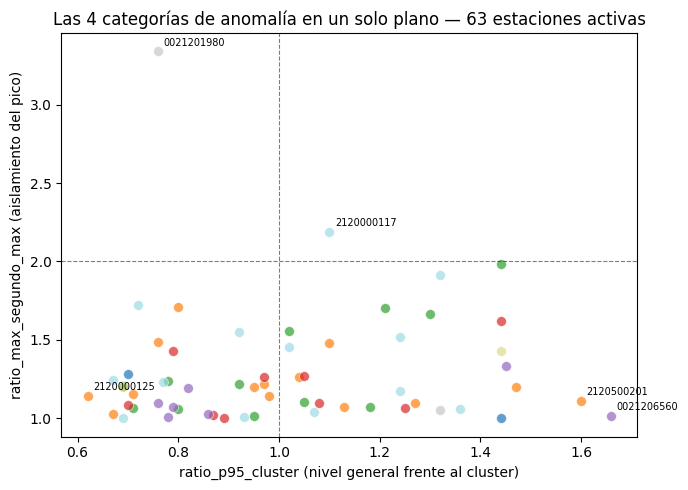

6 estación(es) candidata(s) en el plano (nueva: 4):


,codigo,nombre,cluster_geografico,tamano_cluster,ratio_p95_cluster,ratio_max_segundo_max,ya_investigada
25,2306500204,ALTO DEL VINO [2306500204],6,1,NaN,2.151,False
26,2120000125,COLEGIO SORRENTO (SEDE B SAN RAFAEL) (IED) [2...,2,14,0.62,1.144,False
47,2120000117,COLEGIO MORALBA SURORIENTAL (IED) [2120000117],10,13,1.10,2.189,False
54,0021201980,GUADALUPE - AUT [21201980],8,2,0.76,3.341,False
14,2120500201,VITELMA [2120500201],2,14,1.60,1.112,True
57,0021206560,INEM KENNEDY [21206560],5,7,1.66,1.015,True



1 estación(es) sin comparación posible (cluster de 1), con pico aislado notable:


,codigo,nombre,cluster_geografico,ratio_max_segundo_max
25,2306500204,ALTO DEL VINO [2306500204],6,2.151


In [63]:
# Barrido sistemático — plano de 2 ejes, con las 4 excluidas fuera y las ya investigadas marcadas
estaciones_investigadas = [
    '0021206780', '2120000139', '0021206890', '0021206560', '2120500201']

df_activas = df_temporadas.copy()
tamanos_cluster = df_activas.groupby('cluster_geografico').size()
df_activas['tamano_cluster'] = df_activas['cluster_geografico'].map(tamanos_cluster)

fig, ax = plt.subplots(figsize=(7, 5))

for cluster_id, grupo in df_activas.groupby('cluster_geografico'):
    color = colores_cluster.get(cluster_id, '#888780')
    ax.scatter(grupo['ratio_p95_cluster'], grupo['ratio_max_segundo_max'],
               color=color, alpha=0.7, s=50, edgecolor='white', linewidth=0.5)

ax.axvline(1, color='#262626', lw=0.8, linestyle='--', alpha=0.6)
ax.axhline(2, color='#262626', lw=0.8, linestyle='--', alpha=0.6)

candidatas = df_activas[
    (df_activas['ratio_p95_cluster'] > 1.5) | (df_activas['ratio_p95_cluster'] < 1 / 1.5) |
    (df_activas['ratio_max_segundo_max'] > 2)
].copy()
candidatas['ya_investigada'] = candidatas['codigo'].isin(estaciones_investigadas)

for _, fila in candidatas.iterrows():
    ax.annotate(fila['codigo'], (fila['ratio_p95_cluster'], fila['ratio_max_segundo_max']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

# Sin comparación posible (cluster de tamaño 1) — se listan aparte, no se fuerza una posición x arbitraria
sin_comparacion = df_activas[df_activas['ratio_p95_cluster'].isna() & (df_activas['ratio_max_segundo_max'] > 2)]

ax.set_xlabel('ratio_p95_cluster (nivel general frente al cluster)')
ax.set_ylabel('ratio_max_segundo_max (aislamiento del pico)')
ax.set_title(f'Las 4 categorías de anomalía en un solo plano — {len(df_activas)} estaciones activas')
plt.tight_layout()
plt.savefig('img-barrido_4_cuadrantes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{len(candidatas)} estación(es) candidata(s) en el plano (nueva: {(~candidatas['ya_investigada']).sum()}):")
display(candidatas[['codigo', 'nombre', 'cluster_geografico', 'tamano_cluster',
                     'ratio_p95_cluster', 'ratio_max_segundo_max', 'ya_investigada']].sort_values('ya_investigada'))

if len(sin_comparacion) > 0:
    print(f"\n{len(sin_comparacion)} estación(es) sin comparación posible (cluster de 1), con pico aislado notable:")
    display(sin_comparacion[['codigo', 'nombre', 'cluster_geografico', 'ratio_max_segundo_max']])

#### 4.7.1 Guadalupe, `0021201980`

Con el criterio de vecindad usado en esta notebook (16 km + altitud ≤300 m), el cluster geográfico de esta estación tiene una sola vecina (`0035025060`) — comparación de baja potencia estadística, similar a otros casos de esta sección. `ratio_p95_cluster` = 0.76 (nivel general normal); `ratio_max_segundo_max` = 3.34, el más extremo de toda la red — su día más lluvioso (86.2 mm, 2024-11-05) se despega dramáticamente de su propio segundo lugar histórico.

El máximo por temporada de la vecina confirma actividad convectiva real y sustancial durante la misma ventana del pico: `0035025060` alcanza su propio máximo de 31.6 mm en `SON_24` (aunque en otra fecha) — consistente con una temporada de lluvia fuerte extendida en la zona, no un trimestre tranquilo interrumpido por un solo día anómalo. En el resto de las temporadas, ambas estaciones muestran máximos del mismo orden de magnitud (`MAM_25`: 19.7 vs. 22.8), sin que Guadalupe domine sistemáticamente.

**Decisión: se conserva en el dataset final.** El nivel general es normal, la temporada del pico muestra actividad regional real, y la curva sub-horaria del propio día (ascenso y descenso concentrado en 1.5-2 horas) tiene forma de tormenta convectiva genuina, no de artefacto mecánico.

In [64]:
# Perfil de la estación Guadalupe, 0021201980, y de todo su cluster geográfico
codigo_objetivo = '0021201980'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_cluster_guadalupe = df_temporadas[df_temporadas['cluster_geografico'] == cluster_id][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global']
].sort_values('codigo', key=lambda s: s != codigo_objetivo)  # objetivo primero

display(perfil_cluster_guadalupe)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global
54,0021201980,GUADALUPE - AUT [21201980],8,Automática con Telemetría,3227.0,0.484,0.533,0.0,0.593,0.76,3.341,2024-11-05,86.2
49,0035025060,LA BOLSA [35025060],8,"Automática con Telemetría, Convencional",3195.0,0.000,0.000,0.0,0.352,1.32,1.053,2024-11-13,31.6


In [65]:
tabla_guadalupe = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

columnas_max = ['codigo', 'objetivo'] + [c for c in tabla_guadalupe.columns if c.endswith('_max')]
display(tabla_guadalupe[columnas_max])

,codigo,objetivo,DEF_24_max,MAM_24_max,JJA_24_max,SON_24_max,DEF_25_max,MAM_25_max,JJA_25_max,SON_25_max
1,0021201980,True,13.2,9.8,NaN,86.2,17.5,19.7,9.5,25.8
0,0035025060,False,NaN,NaN,NaN,31.6,3.9,22.8,19.7,17.1


#### 4.7.2 Moraleja Suroriental, `2120000117`

Con el criterio de vecindad de esta notebook, comparte cluster con 12 vecinas (cluster 10). El desglose por temporada muestra las 8 dentro del rango normal — sin patrón de nivel general anómalo. Entra al barrido únicamente por `ratio_max_segundo_max` (2.19): su pico (49.9mm, 2025-04-25) se despega de su propio segundo lugar histórico. Esa misma fecha, sin embargo, es el máximo estacional propio de al menos otras 5 estaciones del mismo cluster (con magnitudes de 25 a 54.5mm) — consistente con un evento convectivo regional real que afectó a todo el sector, no un artefacto aislado de esta estación. Se conserva en el dataset final.

**Decisión: se conserva en el dataset final.**

In [66]:
# Perfil de la estación Moraleja Suroriental, 2120000117, y de todo su cluster geográfico
codigo_objetivo = '2120000117'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]

perfil_cluster_moraleja = df_temporadas[df_temporadas['cluster_geografico'] == cluster_id][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global']
].sort_values('codigo', key=lambda s: s != codigo_objetivo)

display(perfil_cluster_moraleja)

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global
47,2120000117,COLEGIO MORALBA SURORIENTAL (IED) [2120000117],10,Automática con Telemetría,2971.0,0.407,0.685,0.435,0.857,1.10,2.189,2025-04-25,49.9
0,2120000101,ALTOS DE LA ESTANCIA [2120000101],10,Automática con Telemetría,2960.0,0.549,0.935,0.685,0.857,0.72,1.721,2024-11-22,33.9
2,2120000169,COLEGIO LA BELLEZA (IED) [2120000169],10,Automática con Telemetría,2949.0,0.549,0.935,0.728,0.835,1.07,1.037,2025-04-25,25.0
3,2120000127,COLEGIO EDUARDO UMAÑA [2120000127],10,Automática con Telemetría,2923.0,0.549,0.935,0.717,0.857,0.93,1.008,2025-04-27,23.8
9,2120000128,COLEGIO GABRIEL GARCIA MARQUEZ [2120000128],10,Automática con Telemetría,3055.0,0.538,0.924,0.707,0.857,1.02,1.454,2025-04-25,31.7
20,2120000134,COLEGIO LOS ALPES SEDE A [2120000134],10,Automática con Telemetría,2875.0,0.549,0.935,0.707,0.835,1.32,1.912,2025-04-25,54.5
21,2120000126,COLEGIO CIUDAD DE VILLAVICENCIO [2120000126],10,Automática con Telemetría,2923.0,0.549,0.935,0.717,0.846,1.24,1.516,2025-04-27,32.6
29,2120000129,COLEGIO OFELIA URIBE ACOSTA [2120000129],10,Automática con Telemetría,2815.0,0.549,0.935,0.696,0.857,0.92,1.551,2025-04-25,30.7
31,2120000106,GRAN BRETAÑA [2120000106],10,Automática con Telemetría,3087.0,0.549,0.902,0.674,0.857,0.67,1.245,2024-10-05,32.5
32,2120000132,COLEGIO EL TESORO DE LA CUMBRE [2120000132],10,Automática con Telemetría,2816.0,0.549,0.935,0.707,0.857,0.77,1.230,2025-10-13,28.3


In [67]:
tabla_moraleja = tabla_extremos_cluster(cluster_id=cluster_id, codigo_objetivo=codigo_objetivo, bandas=BANDAS)

resumen_rango = []
for temporada in BANDAS.keys():
    col = f'{temporada}_p95'
    vecinas_valores = tabla_moraleja.loc[~tabla_moraleja['objetivo'], col].dropna()
    objetivo_valor = tabla_moraleja.loc[tabla_moraleja['objetivo'], col].values[0]
    if len(vecinas_valores) == 0 or pd.isna(objetivo_valor):
        continue
    rango_min, rango_max = vecinas_valores.min(), vecinas_valores.max()
    fuera_de_rango = objetivo_valor > rango_max or objetivo_valor < rango_min
    if objetivo_valor > rango_max:
        exceso_abs = objetivo_valor - rango_max
        exceso_rel = exceso_abs / rango_max if rango_max > 0 else np.nan
    elif objetivo_valor < rango_min:
        exceso_abs = objetivo_valor - rango_min
        exceso_rel = exceso_abs / rango_min if rango_min > 0 else np.nan
    else:
        exceso_abs, exceso_rel = 0.0, 0.0
    resumen_rango.append({
        'temporada': temporada, 'objetivo': round(objetivo_valor, 1),
        'vecinas_min': round(rango_min, 1), 'vecinas_max': round(rango_max, 1),
        'fuera_de_rango': fuera_de_rango,
        'exceso_rel_%': round(exceso_rel * 100, 1) if pd.notna(exceso_rel) else np.nan,
        'confiable': rango_max >= umbral_magnitud_minima if objetivo_valor > rango_max else rango_min >= umbral_magnitud_minima,
    })
display(pd.DataFrame(resumen_rango))

,temporada,objetivo,vecinas_min,vecinas_max,fuera_de_rango,exceso_rel_%,confiable
0,DEF_24,8.3,2.3,15.1,False,0.0,True
1,MAM_24,1.7,0.7,3.4,False,0.0,False
2,JJA_24,0.3,0.0,0.9,False,0.0,False
3,SON_24,10.9,6.4,19.9,False,0.0,True
4,DEF_25,3.7,1.7,7.0,False,0.0,False
5,MAM_25,10.0,5.0,14.2,False,0.0,True
6,JJA_25,7.5,3.1,14.8,False,0.0,True
7,SON_25,10.2,5.5,10.6,False,0.0,True


#### 4.7.4 Alto del Vino, `2306500204`

Es la única estación de su cluster geográfico (tamaño 1) — no hay vecinas con las que comparar `ratio_p95_cluster`. Su `ratio_max_segundo_max` es 2.15: su día más lluvioso (2024-11-19, 119.6 mm) se despega de forma moderada de su propio segundo lugar histórico.

Sin vecinas de cluster, la corroboración disponible viene de comparar la fecha del pico contra el resto de la red: otras 4 estaciones, repartidas en un arco amplio del noroccidente de la Sabana (San Francisco a Funza), registran su propio máximo esa misma fecha (2024-11-19) — consistente con un evento regional real de alcance extenso, no una tormenta hiperlocal ni un artefacto aislado.

**Decisión: se conserva en el dataset final.** El pico está razonablemente corroborado a nivel de red, sin otra señal (cobertura, cadencia) que sugiera un problema estructural de la estación.

In [68]:
# Perfil Alto del Vino, 2306500204
codigo_objetivo = '2306500204'
cluster_id = df_temporadas.loc[df_temporadas['codigo'] == codigo_objetivo, 'cluster_geografico'].values[0]
tamano = df_temporadas.loc[df_temporadas['cluster_geografico'] == cluster_id].shape[0]

perfil_vino = df_temporadas[df_temporadas['codigo'] == codigo_objetivo][
    ['codigo', 'nombre', 'cluster_geografico', 'tecnologia', 'altitud',
     'DEF_24_mean_dias_con_dato', 'MAM_24_mean_dias_con_dato', 'JJA_24_mean_dias_con_dato', 'SON_24_mean_dias_con_dato',
     'ratio_p95_cluster', 'ratio_max_segundo_max',
     'fecha_max_global', 'precip_max_global']
]
display(perfil_vino)
print(f"\nCluster {cluster_id}, tamaño {tamano}")

,codigo,nombre,cluster_geografico,tecnologia,altitud,DEF_24_mean_dias_con_dato,MAM_24_mean_dias_con_dato,JJA_24_mean_dias_con_dato,SON_24_mean_dias_con_dato,ratio_p95_cluster,ratio_max_segundo_max,fecha_max_global,precip_max_global
25,2306500204,ALTO DEL VINO [2306500204],6,Automática con Telemetría,2872.0,0.0,0.0,0.0,0.352,NaN,2.151,2024-11-19,59.8



Cluster 6, tamaño 1


In [69]:
codigo_objetivo = '2306500204'
fecha_pico = pd.Timestamp('2024-11-19')

# Estaciones cuyo propio máximo estacional cae exactamente en esa fecha
comparten_fecha = df_temporadas[df_temporadas['fecha_max_global'] == fecha_pico][
    ['codigo', 'nombre', 'cluster_geografico', 'latitud', 'longitud', 'precip_max_global']
].sort_values('precip_max_global', ascending=False)

print(f"{len(comparten_fecha)} estación(es) con su máximo global exactamente en {fecha_pico.date()}:")
display(comparten_fecha)

3 estación(es) con su máximo global exactamente en 2024-11-19:


,codigo,nombre,cluster_geografico,latitud,longitud,precip_max_global
25,2306500204,ALTO DEL VINO [2306500204],6,4.877,-74.288,59.8
63,0021206600,NUEVA GENERACION [21206600],3,4.787,-74.102,52.7
55,0021205420,TIBAITATA [21205420],5,4.689,-74.206,35.4


## Conclusiones

La revisión de calidad de las 66 estaciones de ground truth combinó tres frentes complementarios: metadatos del catálogo IDEAM (Sección 2), precisión decimal del instrumento (Sección 3), y homogeneidad de las series diarias — saltos abruptos, cobertura por temporada, y consistencia espacial frente al cluster geográfico de cada estación (Sección 4).

**Criterio de vecindad.** La comparación entre estaciones se hizo mediante clustering jerárquico de enlace completo, con dos condiciones simultáneas: distancia horizontal ≤16 km (Casallas-García et al., 2023) y diferencia de altitud ≤300 m (umbral derivado empíricamente del percentil 75 de diferencias de altitud entre pares de estaciones cercanas de la propia red — Sección 1.2). Este criterio combinado resultó consecuente con un análisis geográfico realizado con un umbral distinto (20 km, sin restricción de altitud, no documentado en esta notebook): las anomalías más extremas (El Dorado, Puente Aranda) se sostuvieron bajo ambos criterios, mientras que casos de magnitud intermedia (Tibaitatá) solo mostraron evidencia real de anomalía bajo uno de los dos — consistente con que la restricción de altitud captura información real, no redundante.

**Criterios de exclusión aplicados**, con estándar de evidencia explícitamente distinto entre ellos:

- **Criterio #1 — Resolución instrumental insuficiente:** se documenta como limitación, sin excluir, cuando el instrumento no alcanza el piso de detección del umbral operativo de 0.1 mm/h. Aplica a `2120500135` y `0021205910` (resolución de 0.2 mm, sin evidencia de contaminación).
- **Criterio #2 — Contaminación física confirmada:** mecanismo físico identificable, no relacionado con precipitación, que persiste tras remover episodios puntuales. Aplica a `0021205791` (El Dorado — vibración del entorno aeroportuario, confirmada en registro sub-horario).
- **Criterio #3 — Anomalía estadística recurrente sin mecanismo confirmado:** desviación sistemática frente al cluster geográfico, sostenida en la mayoría de las temporadas evaluables con magnitud confiable, sin causa física identificada. Aplica a `2120500204` (Puente Aranda) y `0021206780` (La Independencia).



**Dataset final: 63 de 66 estaciones.**

| Código | Nombre | Criterio | Motivo resumido |
|---|---|---|---|
| `0021205791` | El Dorado CATAM | #2 | Contaminación por vibración (entorno aeroportuario), picos regulares no convectivos confirmados en sub-horario |
| `2120500204` | IDEAM Puente Aranda | #3 | Sobrerreporte sistemático en la mayoría de las temporadas evaluables |
| `0021206780` | La Independencia | #3 | Subreporte confiable y consistente en 2 temporadas de magnitud sustancial, cobertura propia descartada como explicación alternativa |

**Conservadas con limitación documentada (Criterio #1):** `2120500135`, `0021205910` — resolución de 0.2 mm, sin contaminación.

**Candidatas investigadas y conservadas**, sin alcanzar el estándar del Criterio #3 — cada una con una anomalía puntual de una sola temporada, o explicada por comparación de baja potencia estadística (clusters de 1-2 miembros) con diferencia de altitud plausible: `0021201980` (Guadalupe), `2306500204` (Alto del Vino), `0021206560` (INEM Kennedy), `2120500201` (Vitelma), `2120000125` (Colegio Sorrento), `0021205420` (Tibaitatá) y `2120000117` (Moraleja Suroriental).

In [70]:
estaciones_excluidas = ['0021205791', '2120500204', '0021206780']

codigos_finales = [c for c in df_temporadas['codigo'] if c not in estaciones_excluidas]

with open('estaciones_finales-despues_de_qc.txt', 'w') as f:
    f.write('\n'.join(codigos_finales))

print(f"Guardado: codigos_finales.txt — {len(codigos_finales)} estaciones")

Guardado: codigos_finales.txt — 63 estaciones
